In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('default')
sns.set_palette("husl")


In [2]:
# Load and prepare data for behavioral classification
df = pd.read_csv('../../../../Thomson Lab Dropbox/David Larios/activedrops/main/all/motor_dataset.csv')

# Keep essential columns for behavioral analysis (removed Translation Rate aa_s as it was faulty)
columns_to_keep = ['time (s)',  'Protein Concentration_nM', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'velocity magnitude [m/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'protein', 'DNA nM']
df = df[columns_to_keep]

# Remove rows with missing protein names
df = df.dropna(subset=['protein'])

# Remove proteins that have only NaNs in velocity magnitude column
print("Before filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")

# Check which proteins have only NaN velocity measurements
velocity_nan_by_protein = df.groupby('protein')['velocity magnitude [m/s]_mean'].apply(lambda x: x.isna().all())
proteins_with_nan_velocity = velocity_nan_by_protein[velocity_nan_by_protein].index.tolist()

print(f"\nProteins with only NaN velocity measurements: {proteins_with_nan_velocity}")

# Remove these proteins
df = df[~df['protein'].isin(proteins_with_nan_velocity)]

print(f"\nAfter filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique proteins: {df['protein'].nunique()}")
print(f"Remaining proteins: {df['protein'].unique()}")

# Don't create protein labels yet - we'll do that after filtering

# Check data quality
print(f"\nData quality check:")
print(f"Rows with valid velocity data: {df['velocity magnitude [m/s]_mean'].notna().sum()}")
print(f"Rows with valid time data: {df['time (s)'].notna().sum()}")
print(f"Rows with valid protein data: {df['protein'].notna().sum()}")

print(f"\nData shape: {df.shape}")
print(f"Time range: {df['time (s)'].min():.1f} to {df['time (s)'].max():.1f} seconds")
print(f"Number of unique motor conditions: {df['protein'].nunique()}")


Before filtering:
Total rows: 182000
Unique proteins: 17

Proteins with only NaN velocity measurements: ['B', 'BleSto', 'E', 'F']

After filtering:
Total rows: 177776
Unique proteins: 13
Remaining proteins: ['A' 'H' 'C' 'G' 'D' 'ThTr' 'AcSu2' 'DiPu' 'HeAl' 'NaGr' 'AdPa' 'Unc'
 'Kif5']

Data quality check:
Rows with valid velocity data: 122771
Rows with valid time data: 177776
Rows with valid protein data: 177776

Data shape: (177776, 13)
Time range: 0.0 to 156600.0 seconds
Number of unique motor conditions: 13


In [3]:
# Find top 3 DNA concentrations with highest speeds for each protein
print(f"\nFinding top 3 DNA concentrations with highest speeds for each protein...")

# First, let's see what proteins and concentrations we have
print(f"Available proteins: {sorted(df['protein'].unique())}")
print(f"Available DNA concentrations: {sorted(df['DNA nM'].unique())}")

# Calculate mean velocity for each protein-DNA combination
velocity_summary = df.groupby(['protein', 'DNA nM'])['velocity magnitude [m/s]_mean'].mean().reset_index()
velocity_summary = velocity_summary.sort_values(['protein', 'velocity magnitude [m/s]_mean'], ascending=[True, False])

# Get top 3 concentrations for each protein
top_concentrations = {}
for protein in df['protein'].unique():
    protein_data = velocity_summary[velocity_summary['protein'] == protein]
    top_3 = protein_data.head(3)['DNA nM'].tolist()
    top_concentrations[protein] = top_3
    print(f"{protein}: {top_3} nM (speeds: {protein_data.head(3)['velocity magnitude [m/s]_mean'].values})")

# Create filter mask for top 3 concentrations per protein
filter_mask = df.apply(lambda row: row['DNA nM'] in top_concentrations.get(row['protein'], []), axis=1)
df_filtered = df[filter_mask].copy()

print(f"\nBefore filtering:")
print(f"Total rows: {len(df)}")
print(f"Unique motor conditions: {df['protein'].nunique()}")

print(f"\nAfter filtering for top 3 concentrations per protein:")
print(f"Total rows: {len(df_filtered)}")
print(f"Unique motor conditions: {df_filtered['protein'].nunique()}")

# Now create the protein labels with DNA concentrations
df_filtered['protein'] = df_filtered['protein'].astype(str) + '-' + df_filtered['DNA nM'].astype(str) + 'nM'

print(f"\nFinal motor conditions: {sorted(df_filtered['protein'].unique())}")
print(f"DNA concentrations used: {sorted(df_filtered['DNA nM'].unique())}")

# Use the filtered dataframe
df = df_filtered

print(f"\nFinal data shape: {df.shape}")
print(f"Time range: {df['time (s)'].min():.1f} to {df['time (s)'].max():.1f} seconds")
print(f"Number of unique motor conditions: {df['protein'].nunique()}")



Finding top 3 DNA concentrations with highest speeds for each protein...
Available proteins: ['A', 'AcSu2', 'AdPa', 'C', 'D', 'DiPu', 'G', 'H', 'HeAl', 'Kif5', 'NaGr', 'ThTr', 'Unc']
Available DNA concentrations: [1.25, 2.5, 5.0, 8.0, 10.0, 20.0, 40.0, 80.0, 85.0, 160.0]
A: [160.0, 80.0, 40.0] nM (speeds: [1.60093946e-08 9.03124605e-09 3.10852066e-09])
H: [40.0, 160.0, 80.0] nM (speeds: [9.16761421e-08 9.06368500e-08 9.01163548e-08])
C: [20.0, 160.0, 80.0] nM (speeds: [5.08994191e-08 4.01019085e-08 3.48799789e-08])
G: [160.0, 10.0, 5.0] nM (speeds: [2.96002261e-08 2.54275059e-08 1.67038529e-08])
D: [10.0, 5.0, 1.25] nM (speeds: [2.56815394e-07 2.41800046e-07 2.25071650e-07])
ThTr: [8.0, 5.0, 10.0] nM (speeds: [1.58910605e-07 9.43697730e-08 8.81643816e-08])
AcSu2: [1.25, 2.5, 5.0] nM (speeds: [2.23565893e-08 1.62012634e-08 4.44789839e-09])
DiPu: [10.0, 20.0, 40.0] nM (speeds: [2.23868987e-08 2.04198929e-08 1.83565899e-08])
HeAl: [1.25, 2.5, 40.0] nM (speeds: [4.01829823e-07 3.42430928e

In [4]:
df

,time (s),Protein Concentration_nM,vorticity [1/s]_mean,divergence [1/s]_mean,velocity magnitude [m/s]_mean,shear [1/s]_mean,strain [1/s]_mean,correlation length [m]_mean,distance [m]_mean,power [W]_mean,work [J]_mean,protein,DNA nM
1340,18000.0,118.321619,-1.187741e-07,7.265161e-07,2.470548e-09,2.378770e-07,-2.650674e-07,0.000358,0.000146,9.498503e-23,6.729736e-19,A-40.0nM,40.0
1341,18600.0,122.745058,-2.041084e-07,4.630435e-07,6.465871e-10,2.507637e-07,-1.935923e-07,0.000351,0.000147,6.795401e-24,6.730761e-19,A-40.0nM,40.0
1342,19200.0,126.728412,-1.402597e-07,1.545595e-07,9.077962e-10,1.517385e-07,-2.334597e-07,0.000343,0.000147,1.397555e-23,6.731130e-19,A-40.0nM,40.0
1343,19800.0,131.528818,-7.681706e-08,3.202855e-07,7.193798e-10,2.898016e-08,-3.150365e-07,0.000337,0.000148,9.132618e-24,6.731251e-19,A-40.0nM,40.0
1344,20400.0,135.586103,-1.019143e-07,1.454392e-07,4.869781e-10,2.974411e-07,-2.469383e-07,0.000331,0.000148,4.336103e-24,6.731418e-19,A-40.0nM,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
243916,131220.0,122.844224,7.554028e-08,6.000483e-07,6.008068e-10,1.705629e-07,-1.453127e-07,0.000112,0.000722,5.768031e-23,5.727192e-18,Kif5-160.0nM,160.0
243917,131265.0,122.777871,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5-160.0nM,160.0
243918,131310.0,122.759158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5-160.0nM,160.0
243919,131355.0,122.815775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kif5-160.0nM,160.0


## Step 1: Create Velocity Over Time Matrix
As requested by Matt: "If you look at velocity over time for all motors as one matrix-- can we generate that matrix and lets look at it"


In [5]:
# Create velocity over time matrix: rows = time points, columns = motor conditions
velocity_matrix = df.pivot_table(
    index='time (s)', 
    columns='protein', 
    values='velocity magnitude [m/s]_mean',
    aggfunc='mean'
)

print(f"Velocity matrix shape: {velocity_matrix.shape}")
print(f"Time range: {velocity_matrix.index.min():.1f} to {velocity_matrix.index.max():.1f} seconds")
print(f"Number of motor conditions: {velocity_matrix.shape[1]}")
print(f"Number of time points: {velocity_matrix.shape[0]}")

# Display the matrix
print("\nFirst few rows and columns of velocity matrix:")
print(velocity_matrix.head())

# Show matrix statistics
velocity_matrix_clean = velocity_matrix.fillna(0)
print(f"\nVelocity matrix statistics:")
print(f"Non-zero velocity measurements: {(velocity_matrix_clean > 0).sum().sum()}")
print(f"Total measurements: {velocity_matrix_clean.size}")
print(f"Percentage with motion: {(velocity_matrix_clean > 0).sum().sum() / velocity_matrix_clean.size * 100:.1f}%")


Velocity matrix shape: (17351, 37)
Time range: 0.0 to 149970.0 seconds
Number of motor conditions: 37
Number of time points: 17351

First few rows and columns of velocity matrix:
protein   A-160.0nM  A-40.0nM  A-80.0nM  AcSu2-1.25nM  AcSu2-2.5nM  \
time (s)                                                             
0.0             NaN       NaN       NaN           NaN          NaN   
15.0            NaN       NaN       NaN           NaN          NaN   
30.0            NaN       NaN       NaN           NaN          NaN   
45.0            NaN       NaN       NaN           NaN          NaN   
60.0            NaN       NaN       NaN           NaN          NaN   

protein   AcSu2-5.0nM  AdPa-10.0nM  AdPa-2.5nM  AdPa-5.0nM  C-160.0nM  ...  \
time (s)                                                               ...   
0.0               NaN          NaN         NaN         NaN        NaN  ...   
15.0              NaN          NaN         NaN         NaN        NaN  ...   
30.0              

## Step 2: Create Comprehensive Features Matrix
Matt: "make a big matrix-- that those 'data features' over time for all motors"

Features: motor concentration, velocity, and derivatives (power, vorticity, divergence, strain, shear)

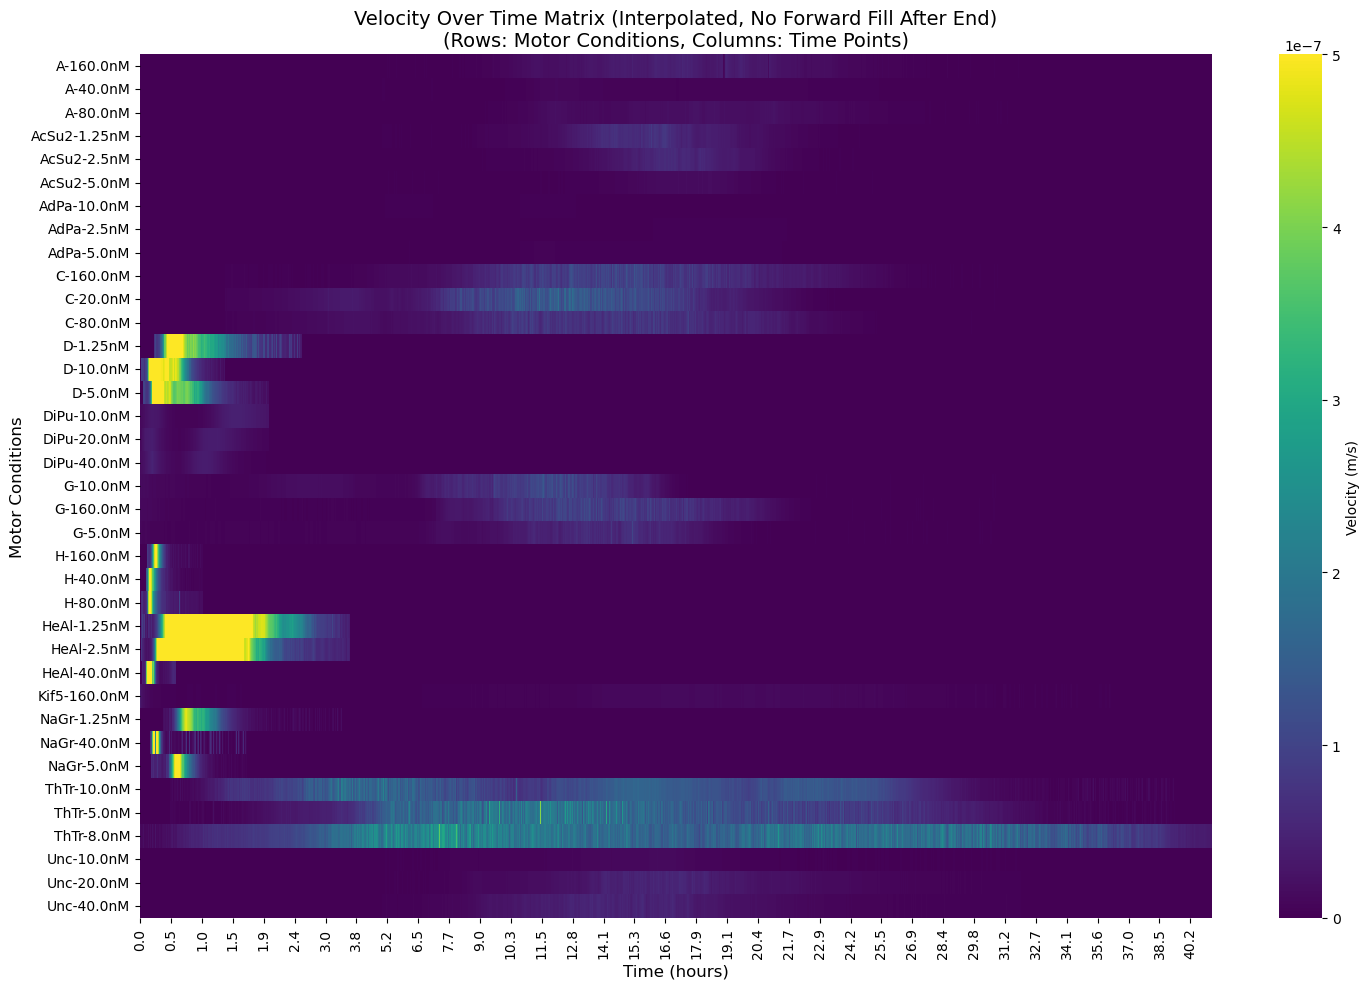

In [6]:
# To avoid artificially extending the last value for motors that finish early,
# we will only interpolate between the first and last valid time points for each motor.
# After the last valid value, we will keep as NaN (not fill forward).

# Interpolate missing values in the velocity matrix (linear, only between valid points)
velocity_matrix_interp = velocity_matrix.copy()
for col in velocity_matrix_interp.columns:
    # Only interpolate between first and last valid index
    s = velocity_matrix_interp[col]
    first_valid = s.first_valid_index()
    last_valid = s.last_valid_index()
    # Interpolate only within the valid range
    s_interp = s.loc[first_valid:last_valid].interpolate(method='linear', limit_direction='both')
    # Reconstruct the full column: keep NaN before/after, interpolated in the middle
    s_new = pd.Series(np.nan, index=s.index)
    s_new.loc[first_valid:last_valid] = s_interp
    velocity_matrix_interp[col] = s_new

# For visualization, fill remaining NaNs with 0 (but do NOT use this for analysis)
velocity_matrix_interp_clean = velocity_matrix_interp.fillna(0)

plt.figure(figsize=(15, 10))

vmax = 0.5e-6

# Plot the heatmap as before
ax = sns.heatmap(
    velocity_matrix_interp_clean.T, 
    cmap='viridis', 
    cbar_kws={'label': 'Velocity (m/s)'},
    xticklabels=500,  # Show every 500th time point (fewer ticks)
    yticklabels=True,
    vmax=vmax
)

# Transform x-tick labels from seconds to hours
xticks = ax.get_xticks()
xtick_labels = velocity_matrix_interp_clean.index.values[xticks.astype(int)]
xtick_labels_hours = xtick_labels / 3600
ax.set_xticklabels([f"{x:.1f}" for x in xtick_labels_hours])

plt.title('Velocity Over Time Matrix (Interpolated, No Forward Fill After End)\n(Rows: Motor Conditions, Columns: Time Points)', fontsize=14)
plt.xlabel('Time (hours)', fontsize=12)
plt.ylabel('Motor Conditions', fontsize=12)

plt.tight_layout()
# Save the last matplotlib figure as JPG with 300 dpi BEFORE plt.show()
plt.savefig("../../../../Downloads/velocity_matrix_interpolated.jpg", format="jpg", dpi=300)

plt.show()


## NMF Analysis: Quantitative Motor Clustering

**Goal**: Use Non-Negative Matrix Factorization to discover quantitative groups of motors and identify which data features best separate them.


In [7]:
# Prepare data for NMF (ensure non-negative)
velocity_data = velocity_matrix_interp_clean.values
if (velocity_data < 0).any():
    velocity_data = velocity_data - velocity_data.min() + 1e-10

print(f"Data prepared for NMF:")
print(f"Shape: {velocity_data.shape}")
print(f"Non-negative: {(velocity_data >= 0).all()}")
print(f"Data range: {velocity_data.min():.2e} to {velocity_data.max():.2e}")


Data prepared for NMF:
Shape: (17351, 37)
Non-negative: True
Data range: 0.00e+00 to 2.19e-06


Data prepared for NMF:
Shape: (17351, 37)
Non-negative: True
Data range: 0.00e+00 to 2.19e-06
Evaluating NMF with different numbers of components...
Components:  1, Reconstruction Error: 0.000000
Components:  2, Reconstruction Error: 0.000000
Components:  3, Reconstruction Error: 0.000000
Components:  4, Reconstruction Error: 0.000000
Components:  5, Reconstruction Error: 0.000000
Components:  6, Reconstruction Error: 0.000000

Elbow detected at 3 components


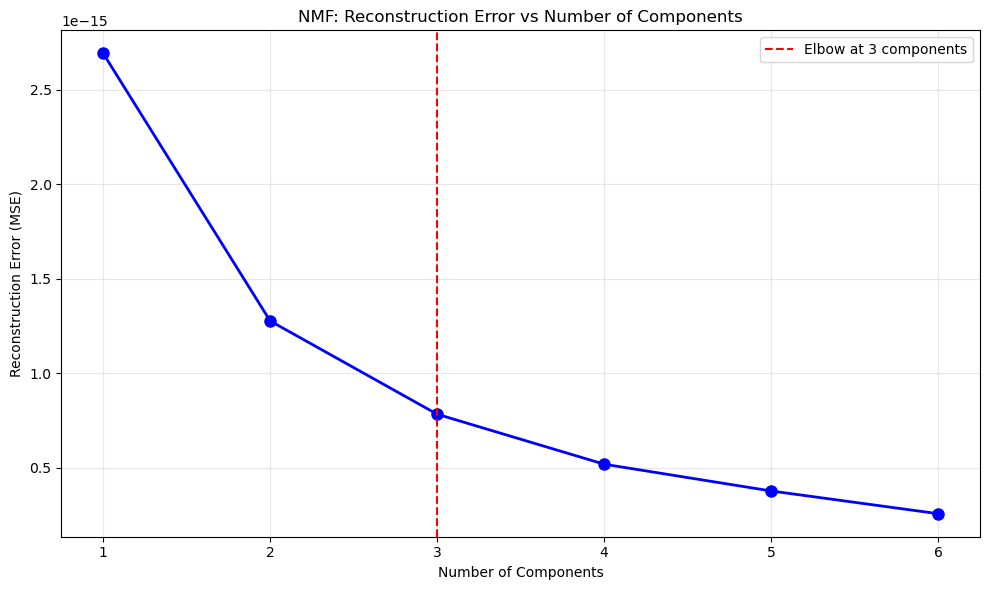

In [8]:
# Import NMF and required libraries
from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Prepare data for NMF (ensure non-negative)
velocity_data = velocity_matrix_interp_clean.values
if (velocity_data < 0).any():
    velocity_data = velocity_data - velocity_data.min() + 1e-10

print(f"Data prepared for NMF:")
print(f"Shape: {velocity_data.shape}")
print(f"Non-negative: {(velocity_data >= 0).all()}")
print(f"Data range: {velocity_data.min():.2e} to {velocity_data.max():.2e}")

# Determine optimal number of NMF components
def evaluate_nmf_components(data, max_components=8):
    """Evaluate NMF with different numbers of components"""
    reconstruction_errors = []
    components_range = range(1, min(max_components + 1, min(data.shape) + 1))
    
    for n_components in components_range:
        try:
            nmf = NMF(n_components=n_components, random_state=42, max_iter=1000)
            W = nmf.fit_transform(data)
            H = nmf.components_
            
            reconstructed = W @ H
            error = mean_squared_error(data, reconstructed)
            reconstruction_errors.append(error)
            
            print(f"Components: {n_components:2d}, Reconstruction Error: {error:.6f}")
            
        except Exception as e:
            print(f"Error with {n_components} components: {e}")
            reconstruction_errors.append(np.inf)
    
    return components_range, reconstruction_errors

# Evaluate different numbers of components
print("Evaluating NMF with different numbers of components...")
components_range, errors = evaluate_nmf_components(velocity_data, max_components=6)

# Plot reconstruction error vs number of components
plt.figure(figsize=(10, 6))
plt.plot(components_range, errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('NMF: Reconstruction Error vs Number of Components')
plt.grid(True, alpha=0.3)

# Find elbow point
if len(errors) > 2:
    second_deriv = np.diff(errors, 2)
    if len(second_deriv) > 0:
        elbow_idx = np.argmax(second_deriv) + 2
        optimal_components = components_range[elbow_idx]
        plt.axvline(x=optimal_components, color='red', linestyle='--', 
                   label=f'Elbow at {optimal_components} components')
        plt.legend()
        print(f"\nElbow detected at {optimal_components} components")
    else:
        optimal_components = 3
        print(f"\nUsing default of {optimal_components} components")
else:
    optimal_components = 3
    print(f"\nUsing default of {optimal_components} components")

plt.tight_layout()
plt.show()


In [9]:
# Perform NMF with optimal number of components
print(f"Performing NMF with {optimal_components} components...")

nmf = NMF(n_components=optimal_components, random_state=42, max_iter=1000)
W = nmf.fit_transform(velocity_data)  # W: time points × components
H = nmf.components_  # H: components × motor conditions

print(f"NMF Results:")
print(f"W shape (time points × components): {W.shape}")
print(f"H shape (components × motor conditions): {H.shape}")

# Calculate reconstruction quality
reconstructed = W @ H
reconstruction_error = mean_squared_error(velocity_data, reconstructed)
print(f"Reconstruction error (MSE): {reconstruction_error:.6f}")

# Create dataframes
W_df = pd.DataFrame(W, 
                   index=velocity_matrix_interp_clean.index,  # time points
                   columns=[f'Component_{i+1}' for i in range(optimal_components)])

H_df = pd.DataFrame(H, 
                   index=[f'Component_{i+1}' for i in range(optimal_components)],
                   columns=velocity_matrix_interp_clean.columns)  # motor conditions

print(f"\nComponent patterns over time (W matrix):")
print(W_df.head())

print(f"\nMotor contributions to components (H matrix):")
print(H_df.head())


Performing NMF with 3 components...
NMF Results:
W shape (time points × components): (17351, 3)
H shape (components × motor conditions): (3, 37)
Reconstruction error (MSE): 0.000000

Component patterns over time (W matrix):
           Component_1  Component_2   Component_3
time (s)                                         
0.0       1.218143e-08     0.000003  2.603820e-07
15.0      1.938542e-08     0.000003  2.544867e-07
30.0      1.345163e-08     0.000002  2.596111e-07
45.0      2.197920e-08     0.000003  2.526056e-07
60.0      2.941079e-08     0.000003  2.465194e-07

Motor contributions to components (H matrix):
protein      A-160.0nM  A-40.0nM  A-80.0nM  AcSu2-1.25nM  AcSu2-2.5nM  \
Component_1   0.000000  0.000000  0.000000      0.000000     0.000000   
Component_2   0.000303  0.000059  0.000166      0.000344     0.000238   
Component_3   0.000000  0.000000  0.000000      0.000000     0.000000   

protein      AcSu2-5.0nM  AdPa-10.0nM  AdPa-2.5nM  AdPa-5.0nM  C-160.0nM  ...  \
Compo

In [10]:
# Find motor groups based on NMF components
print("=== QUANTITATIVE MOTOR GROUPING ===")

# For each motor, find which component it contributes most to
motor_groups = {}
for motor in H_df.columns:
    contributions = H_df[motor]
    primary_component = contributions.idxmax()
    primary_contribution = contributions.max()
    
    motor_groups[motor] = {
        'primary_component': primary_component,
        'primary_contribution': primary_contribution,
        'all_contributions': contributions.to_dict()
    }

# Group motors by their primary component
component_groups = {}
for motor, info in motor_groups.items():
    comp = info['primary_component']
    if comp not in component_groups:
        component_groups[comp] = []
    component_groups[comp].append((motor, info['primary_contribution']))

# Sort motors within each group by contribution strength
for comp in component_groups:
    component_groups[comp].sort(key=lambda x: x[1], reverse=True)

print(f"Found {len(component_groups)} motor groups:")
for comp, motors in component_groups.items():
    print(f"\n{comp} ({len(motors)} motors):")
    for motor, contribution in motors:
        print(f"  {motor}: {contribution:.3f}")

# Calculate group statistics
group_stats = {}
for comp, motors in component_groups.items():
    motor_names = [motor for motor, _ in motors]
    contributions = [contrib for _, contrib in motors]
    
    group_stats[comp] = {
        'n_motors': len(motors),
        'avg_contribution': np.mean(contributions),
        'max_contribution': np.max(contributions),
        'min_contribution': np.min(contributions),
        'std_contribution': np.std(contributions),
        'motors': motor_names
    }

print(f"\n=== GROUP STATISTICS ===")
for comp, stats in group_stats.items():
    print(f"\n{comp}:")
    print(f"  Number of motors: {stats['n_motors']}")
    print(f"  Average contribution: {stats['avg_contribution']:.3f}")
    print(f"  Contribution range: {stats['min_contribution']:.3f} - {stats['max_contribution']:.3f}")
    print(f"  Standard deviation: {stats['std_contribution']:.3f}")
    print(f"  Motors: {', '.join(stats['motors'])}")


=== QUANTITATIVE MOTOR GROUPING ===
Found 3 motor groups:

Component_2 (22 motors):
  ThTr-8.0nM: 0.004
  ThTr-5.0nM: 0.003
  ThTr-10.0nM: 0.002
  C-20.0nM: 0.001
  C-160.0nM: 0.001
  C-80.0nM: 0.001
  G-160.0nM: 0.001
  G-10.0nM: 0.001
  G-5.0nM: 0.000
  Unc-40.0nM: 0.000
  Unc-20.0nM: 0.000
  AcSu2-1.25nM: 0.000
  A-160.0nM: 0.000
  AcSu2-2.5nM: 0.000
  A-80.0nM: 0.000
  Kif5-160.0nM: 0.000
  Unc-10.0nM: 0.000
  AcSu2-5.0nM: 0.000
  A-40.0nM: 0.000
  AdPa-5.0nM: 0.000
  AdPa-10.0nM: 0.000
  AdPa-2.5nM: 0.000

Component_1 (7 motors):
  HeAl-1.25nM: 0.005
  HeAl-2.5nM: 0.004
  D-1.25nM: 0.002
  NaGr-1.25nM: 0.001
  NaGr-5.0nM: 0.001
  DiPu-10.0nM: 0.000
  DiPu-20.0nM: 0.000

Component_3 (8 motors):
  D-5.0nM: 0.002
  D-10.0nM: 0.002
  HeAl-40.0nM: 0.002
  NaGr-40.0nM: 0.001
  H-40.0nM: 0.001
  H-160.0nM: 0.001
  H-80.0nM: 0.001
  DiPu-40.0nM: 0.000

=== GROUP STATISTICS ===

Component_2:
  Number of motors: 22
  Average contribution: 0.001
  Contribution range: 0.000 - 0.004
  Standard

=== CREATING COMPREHENSIVE MULTI-FEATURE MATRIX FOR NMF ===
Available features: ['velocity magnitude [m/s]_mean', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'Protein Concentration_nM']
velocity magnitude [m/s]_mean: (17351, 37)
vorticity [1/s]_mean: (17351, 37)
divergence [1/s]_mean: (17351, 37)
shear [1/s]_mean: (17351, 37)
strain [1/s]_mean: (17351, 37)
correlation length [m]_mean: (17351, 37)
distance [m]_mean: (17351, 37)
power [W]_mean: (17351, 37)
work [J]_mean: (17351, 37)
Protein Concentration_nM: (17351, 37)

Comprehensive matrix shape: (17351, 370)
Features per motor: 10
Total feature columns: 370

Data prepared for NMF:
Shape: (17351, 370)
Non-negative: True
Data range: 0.00e+00 to 3.45e+03
=== PERFORMING NMF WITH COMPREHENSIVE MATRIX ===
Evaluating NMF with comprehensive matrix...
Components:  1, Reconstruction Error: 1615.688342
Components: 

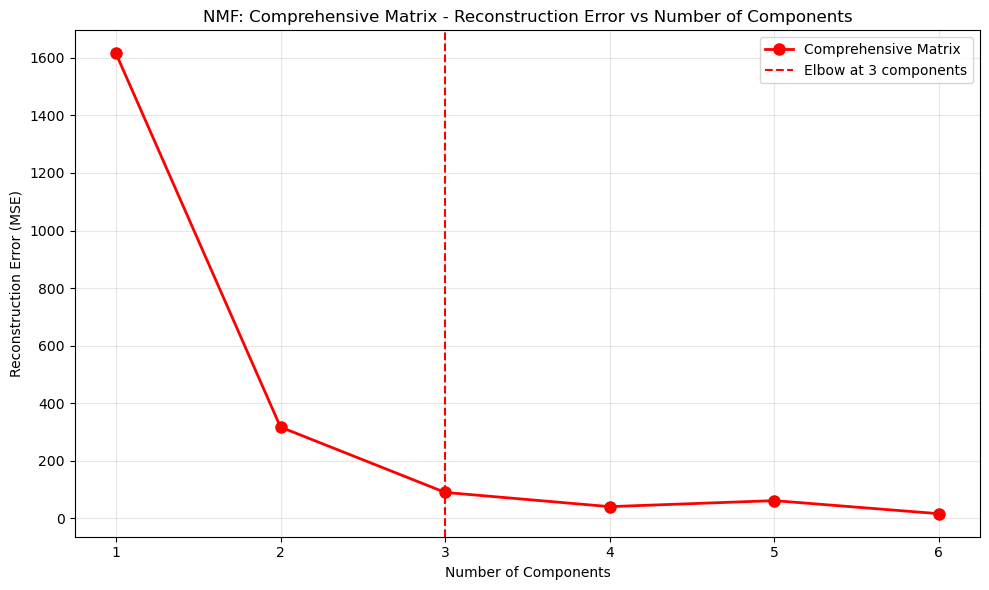

Performing NMF with comprehensive matrix using 3 components...
Comprehensive NMF Results:
W shape (time points × components): (17351, 3)
H shape (components × motor-feature combinations): (3, 370)
Reconstruction error (MSE): 89.886784

Comprehensive component patterns over time (W matrix):
          Component_1  Component_2  Component_3
time (s)                                       
0.0          0.222596     0.093976          0.0
15.0         0.222594     0.093986          0.0
30.0         0.222592     0.093995          0.0
45.0         0.222590     0.094005          0.0
60.0         0.222588     0.094017          0.0

Motor-feature contributions to components (H matrix):
             A-160.0nM_velocity magnitude [m/s]_mean  \
Component_1                             3.217062e-09   
Component_2                             0.000000e+00   
Component_3                             1.673933e-08   

             A-160.0nM_vorticity [1/s]_mean  A-160.0nM_divergence [1/s]_mean  \
Component_1  

In [11]:
# Create comprehensive multi-feature matrix for NMF
print("=== CREATING COMPREHENSIVE MULTI-FEATURE MATRIX FOR NMF ===")

# Define all available features
feature_columns = [
    'velocity magnitude [m/s]_mean',
    'vorticity [1/s]_mean', 
    'divergence [1/s]_mean',
    'shear [1/s]_mean',
    'strain [1/s]_mean',
    'correlation length [m]_mean',
    'distance [m]_mean',
    'power [W]_mean',
    'work [J]_mean',
    'Protein Concentration_nM'
]

print(f"Available features: {feature_columns}")

# Create feature matrices for each feature
comprehensive_data = []
feature_names = []
motor_conditions = list(velocity_matrix_interp_clean.columns)

# Use the same time index as the velocity matrix to ensure all features have the same dimensions
time_index = velocity_matrix_interp_clean.index

for feature in feature_columns:
    if feature in df.columns:
        # Create pivot table for this feature
        feature_matrix = df.pivot_table(
            index='time (s)',
            columns='protein', 
            values=feature,
            aggfunc='mean'
        )
        
        # Reindex to match the velocity matrix time index
        feature_matrix_reindexed = feature_matrix.reindex(time_index)
        
        # Interpolate missing values
        feature_matrix_interp = feature_matrix_reindexed.interpolate(method='linear', axis=0, limit_direction='both')
        feature_matrix_interp = feature_matrix_interp.fillna(method='bfill').fillna(method='ffill')
        feature_matrix_clean = feature_matrix_interp.fillna(0)
        
        # Ensure non-negative for NMF
        feature_data = feature_matrix_clean.values
        if (feature_data < 0).any():
            feature_data = feature_data - feature_data.min() + 1e-10
        
        comprehensive_data.append(feature_data)
        feature_names.extend([f"{feature}_{motor}" for motor in motor_conditions])
        print(f"{feature}: {feature_data.shape}")

# Stack horizontally: each motor gets all features as columns
comprehensive_matrix = np.hstack(comprehensive_data)

print(f"\nComprehensive matrix shape: {comprehensive_matrix.shape}")
print(f"Features per motor: {len(feature_columns)}")
print(f"Total feature columns: {comprehensive_matrix.shape[1]}")

# Prepare data for NMF (ensure non-negative)
if (comprehensive_matrix < 0).any():
    comprehensive_matrix = comprehensive_matrix - comprehensive_matrix.min() + 1e-10

print(f"\nData prepared for NMF:")
print(f"Shape: {comprehensive_matrix.shape}")
print(f"Non-negative: {(comprehensive_matrix >= 0).all()}")
print(f"Data range: {comprehensive_matrix.min():.2e} to {comprehensive_matrix.max():.2e}")

# Use comprehensive matrix instead of velocity-only data
nmf_data = comprehensive_matrix

# Now perform NMF with comprehensive matrix
print("=== PERFORMING NMF WITH COMPREHENSIVE MATRIX ===")

# Evaluate different numbers of components for comprehensive matrix
print("Evaluating NMF with comprehensive matrix...")
components_range_comp, errors_comp = evaluate_nmf_components(nmf_data, max_components=6)

# Plot reconstruction error vs number of components
plt.figure(figsize=(10, 6))
plt.plot(components_range_comp, errors_comp, 'ro-', linewidth=2, markersize=8, label='Comprehensive Matrix')
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('NMF: Comprehensive Matrix - Reconstruction Error vs Number of Components')
plt.grid(True, alpha=0.3)

# Find elbow point for comprehensive matrix
if len(errors_comp) > 2:
    second_deriv_comp = np.diff(errors_comp, 2)
    if len(second_deriv_comp) > 0:
        elbow_idx_comp = np.argmax(second_deriv_comp) + 2
        optimal_components_comp = components_range_comp[elbow_idx_comp]
        plt.axvline(x=optimal_components_comp, color='red', linestyle='--', 
                   label=f'Elbow at {optimal_components_comp} components')
        plt.legend()
        print(f"\nElbow detected at {optimal_components_comp} components")
    else:
        optimal_components_comp = 3
        print(f"\nUsing default of {optimal_components_comp} components")
else:
    optimal_components_comp = 3
    print(f"\nUsing default of {optimal_components_comp} components")

plt.tight_layout()
plt.show()

# Perform NMF with comprehensive matrix
print(f"Performing NMF with comprehensive matrix using {optimal_components_comp} components...")

nmf_comp = NMF(n_components=optimal_components_comp, random_state=42, max_iter=1000)
W_comp = nmf_comp.fit_transform(nmf_data)  # W: time points × components
H_comp = nmf_comp.components_  # H: components × (motor_conditions × features)

print(f"Comprehensive NMF Results:")
print(f"W shape (time points × components): {W_comp.shape}")
print(f"H shape (components × motor-feature combinations): {H_comp.shape}")

# Calculate reconstruction quality
reconstructed_comp = W_comp @ H_comp
reconstruction_error_comp = mean_squared_error(nmf_data, reconstructed_comp)
print(f"Reconstruction error (MSE): {reconstruction_error_comp:.6f}")

# Create dataframes for comprehensive analysis
W_comp_df = pd.DataFrame(W_comp, 
                        index=velocity_matrix_interp_clean.index,  # time points
                        columns=[f'Component_{i+1}' for i in range(optimal_components_comp)])

# H matrix now has dimensions [components × (motor_conditions × n_features)]
H_comp_columns = []
for motor in motor_conditions:
    for feature in feature_columns:
        H_comp_columns.append(f"{motor}_{feature}")

H_comp_df = pd.DataFrame(H_comp, 
                        index=[f'Component_{i+1}' for i in range(optimal_components_comp)],
                        columns=H_comp_columns)

print(f"\nComprehensive component patterns over time (W matrix):")
print(W_comp_df.head())

print(f"\nMotor-feature contributions to components (H matrix):")
print(H_comp_df.head())


In [12]:
# Find motor groups based on comprehensive NMF components
print("=== COMPREHENSIVE MOTOR GROUPING ===")

# For each motor, aggregate contributions across all features
motor_groups_comp = {}
for motor in motor_conditions:
    # Get all columns for this motor (across all features)
    motor_columns = [col for col in H_comp_df.columns if col.startswith(f"{motor}_")]
    
    if motor_columns:
        # Sum contributions across all features for this motor
        motor_contributions = H_comp_df[motor_columns].sum(axis=1)
        primary_component = motor_contributions.idxmax()
        primary_contribution = motor_contributions.max()
        
        motor_groups_comp[motor] = {
            'primary_component': primary_component,
            'primary_contribution': primary_contribution,
            'all_contributions': motor_contributions.to_dict(),
            'feature_contributions': H_comp_df[motor_columns].to_dict()
        }

# Group motors by their primary component
component_groups_comp = {}
for motor, info in motor_groups_comp.items():
    comp = info['primary_component']
    if comp not in component_groups_comp:
        component_groups_comp[comp] = []
    component_groups_comp[comp].append((motor, info['primary_contribution']))

# Sort motors within each group by contribution strength
for comp in component_groups_comp:
    component_groups_comp[comp].sort(key=lambda x: x[1], reverse=True)

print(f"Found {len(component_groups_comp)} motor groups using comprehensive matrix:")
for comp, motors in component_groups_comp.items():
    print(f"\n{comp} ({len(motors)} motors):")
    for motor, contribution in motors:
        print(f"  {motor}: {contribution:.3f}")

# Calculate group statistics
group_stats_comp = {}
for comp, motors in component_groups_comp.items():
    motor_names = [motor for motor, _ in motors]
    contributions = [contrib for _, contrib in motors]
    
    group_stats_comp[comp] = {
        'n_motors': len(motors),
        'avg_contribution': np.mean(contributions),
        'max_contribution': np.max(contributions),
        'min_contribution': np.min(contributions),
        'std_contribution': np.std(contributions),
        'motors': motor_names
    }

print(f"\n=== COMPREHENSIVE GROUP STATISTICS ===")
for comp, stats in group_stats_comp.items():
    print(f"\n{comp}:")
    print(f"  Number of motors: {stats['n_motors']}")
    print(f"  Average contribution: {stats['avg_contribution']:.3f}")
    print(f"  Contribution range: {stats['min_contribution']:.3f} - {stats['max_contribution']:.3f}")
    print(f"  Standard deviation: {stats['std_contribution']:.3f}")
    print(f"  Motors: {', '.join(stats['motors'])}")


=== COMPREHENSIVE MOTOR GROUPING ===
Found 1 motor groups using comprehensive matrix:

Component_1 (37 motors):
  ThTr-8.0nM: 9085.475
  Unc-40.0nM: 4563.945
  Unc-10.0nM: 2295.752
  Unc-20.0nM: 1786.267
  AdPa-5.0nM: 0.118
  C-160.0nM: 0.118
  C-20.0nM: 0.118
  AdPa-2.5nM: 0.083
  C-80.0nM: 0.047
  D-10.0nM: 0.039
  D-1.25nM: 0.038
  D-5.0nM: 0.036
  AcSu2-5.0nM: 0.031
  AdPa-10.0nM: 0.031
  AcSu2-2.5nM: 0.031
  HeAl-1.25nM: 0.030
  DiPu-20.0nM: 0.028
  DiPu-10.0nM: 0.028
  DiPu-40.0nM: 0.028
  G-10.0nM: 0.019
  H-80.0nM: 0.016
  HeAl-2.5nM: 0.016
  AcSu2-1.25nM: 0.009
  G-160.0nM: 0.008
  H-160.0nM: 0.007
  G-5.0nM: 0.007
  H-40.0nM: 0.003
  A-80.0nM: 0.000
  A-40.0nM: 0.000
  A-160.0nM: 0.000
  ThTr-5.0nM: 0.000
  ThTr-10.0nM: 0.000
  NaGr-5.0nM: 0.000
  NaGr-40.0nM: 0.000
  NaGr-1.25nM: 0.000
  Kif5-160.0nM: 0.000
  HeAl-40.0nM: 0.000

=== COMPREHENSIVE GROUP STATISTICS ===

Component_1:
  Number of motors: 37
  Average contribution: 479.252
  Contribution range: 0.000 - 9085.475
 

=== COMPREHENSIVE MOTOR GROUP VISUALIZATION ===


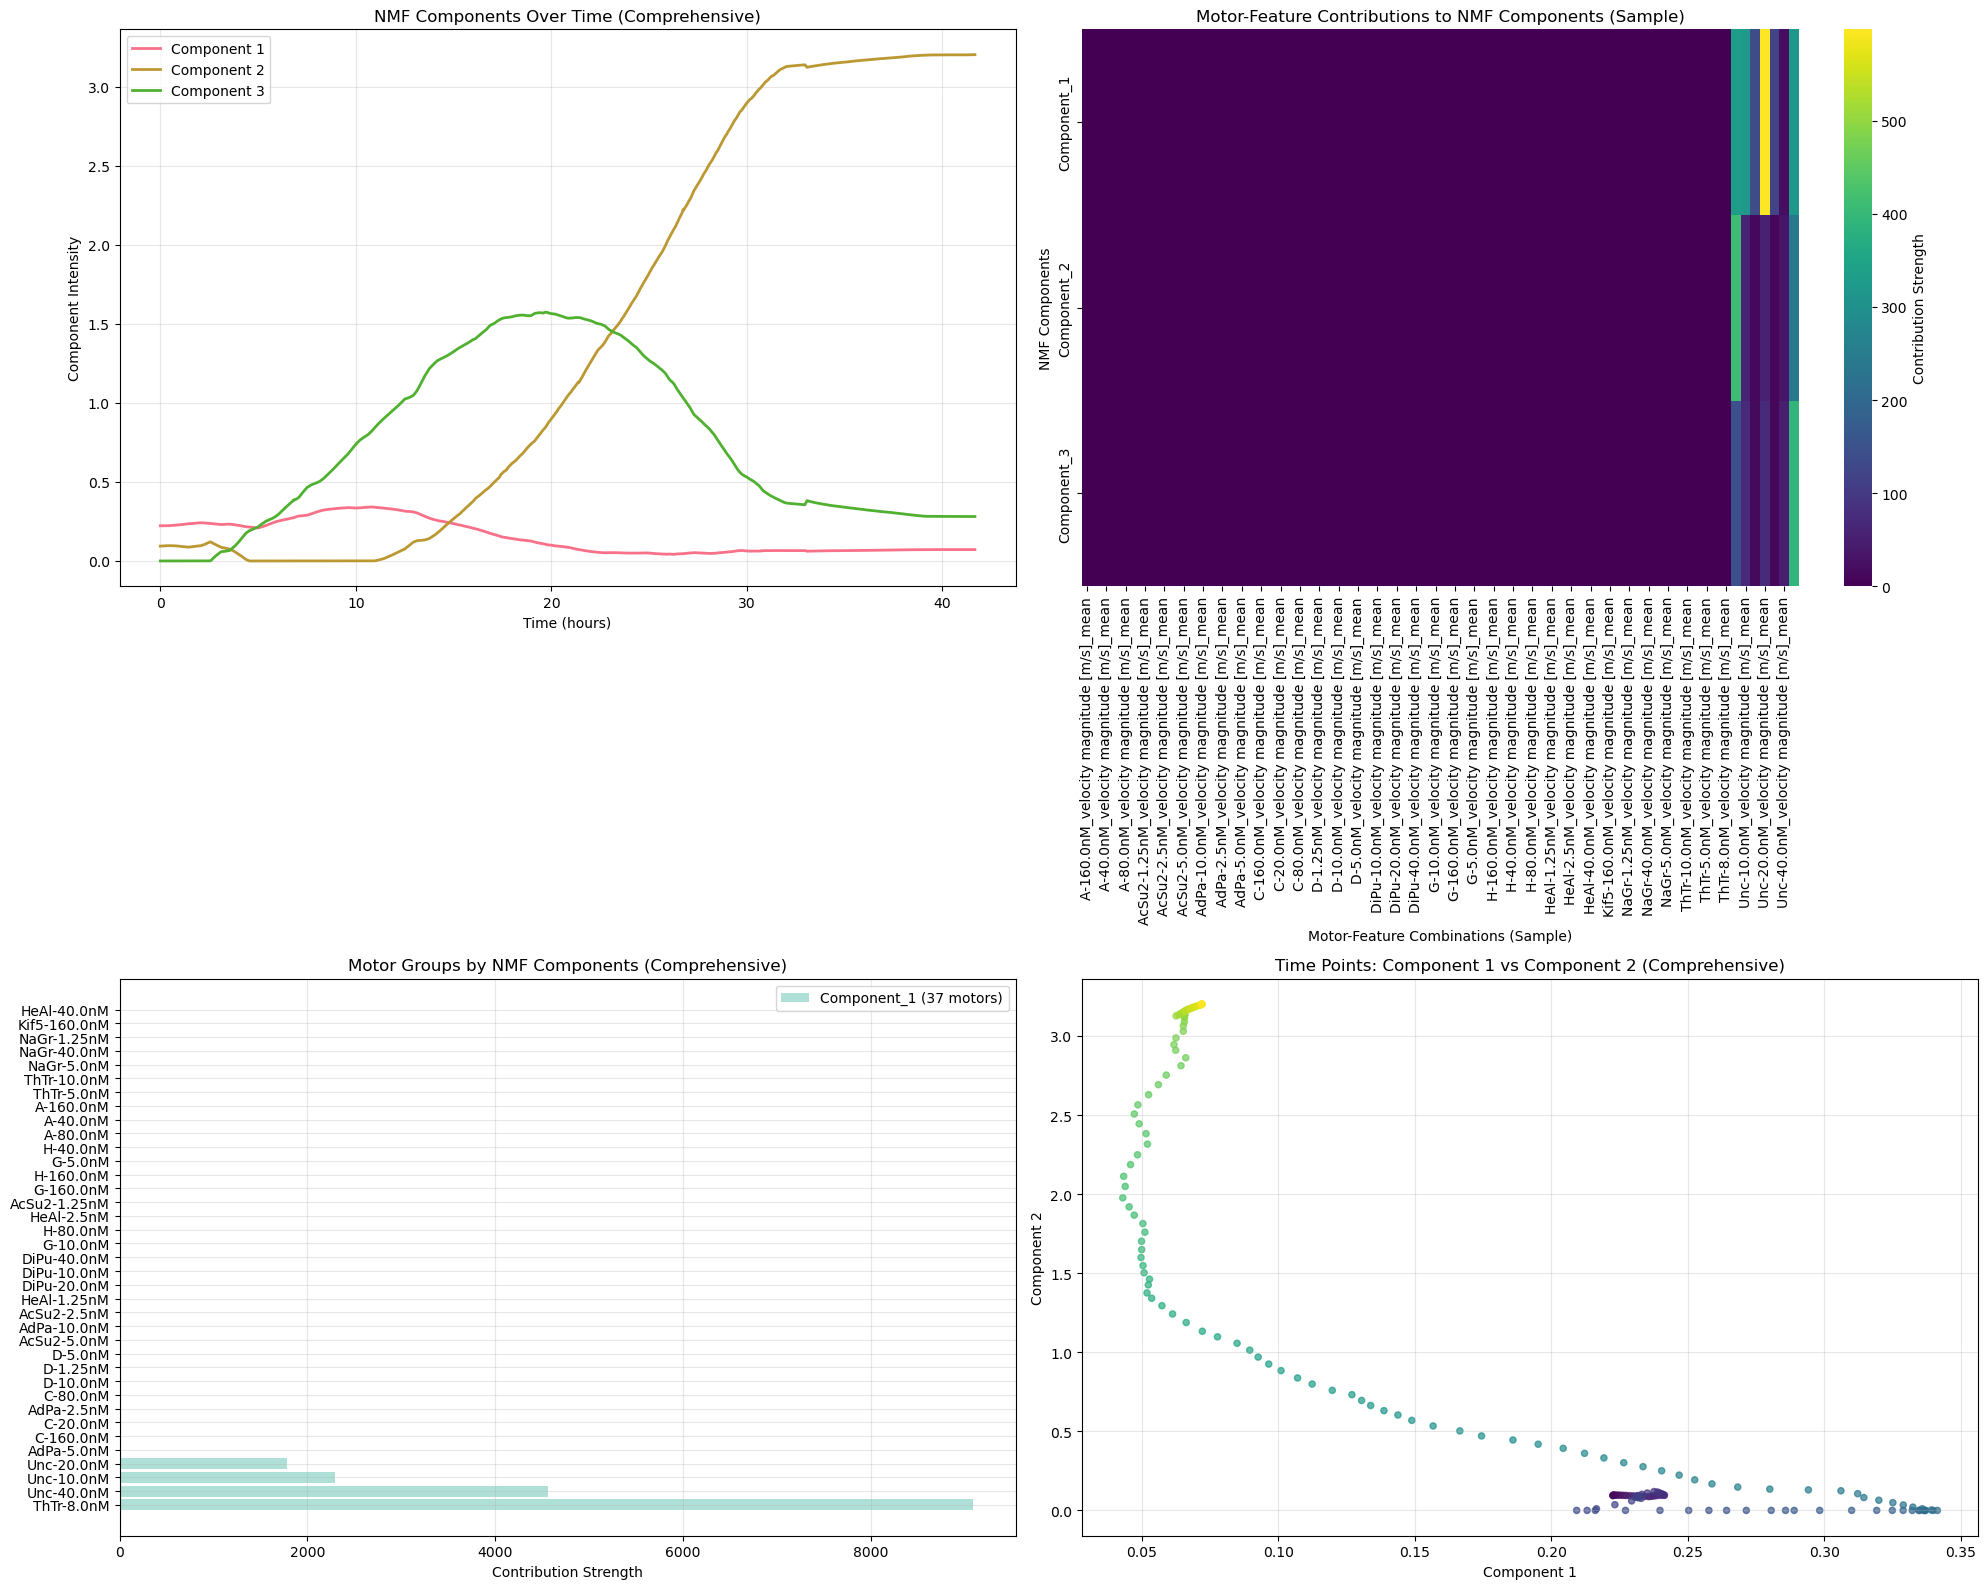


=== DETAILED MOTOR GROUP INFORMATION ===

Component_1 (37 motors):
  ThTr at 8.0nM: 9085.475
  Unc at 40.0nM: 4563.945
  Unc at 10.0nM: 2295.752
  Unc at 20.0nM: 1786.267
  AdPa at 5.0nM: 0.118
  C at 160.0nM: 0.118
  C at 20.0nM: 0.118
  AdPa at 2.5nM: 0.083
  C at 80.0nM: 0.047
  D at 10.0nM: 0.039
  D at 1.25nM: 0.038
  D at 5.0nM: 0.036
  AcSu2 at 5.0nM: 0.031
  AdPa at 10.0nM: 0.031
  AcSu2 at 2.5nM: 0.031
  HeAl at 1.25nM: 0.030
  DiPu at 20.0nM: 0.028
  DiPu at 10.0nM: 0.028
  DiPu at 40.0nM: 0.028
  G at 10.0nM: 0.019
  H at 80.0nM: 0.016
  HeAl at 2.5nM: 0.016
  AcSu2 at 1.25nM: 0.009
  G at 160.0nM: 0.008
  H at 160.0nM: 0.007
  G at 5.0nM: 0.007
  H at 40.0nM: 0.003
  A at 80.0nM: 0.000
  A at 40.0nM: 0.000
  A at 160.0nM: 0.000
  ThTr at 5.0nM: 0.000
  ThTr at 10.0nM: 0.000
  NaGr at 5.0nM: 0.000
  NaGr at 40.0nM: 0.000
  NaGr at 1.25nM: 0.000
  Kif5 at 160.0nM: 0.000
  HeAl at 40.0nM: 0.000

=== MOTOR GROUP SUMMARY TABLE ===
Protein Concentration       Group  Contribution

In [13]:
# Visualize comprehensive motor groups with proper protein labels
print("=== COMPREHENSIVE MOTOR GROUP VISUALIZATION ===")

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Component patterns over time
ax1 = axes[0, 0]
time_hours = velocity_matrix_interp_clean.index / 3600
for i in range(optimal_components_comp):
    ax1.plot(time_hours, W_comp_df.iloc[:, i], label=f'Component {i+1}', linewidth=2)
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Component Intensity')
ax1.set_title('NMF Components Over Time (Comprehensive)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Motor contribution heatmap (comprehensive)
ax2 = axes[0, 1]
# Sample every 5th motor-feature combination for readability
sample_columns = H_comp_df.columns[::5]
sample_H = H_comp_df[sample_columns]
sns.heatmap(sample_H, annot=False, fmt='.2f', cmap='viridis', ax=ax2, 
            cbar_kws={'label': 'Contribution Strength'})
ax2.set_title('Motor-Feature Contributions to NMF Components (Sample)')
ax2.set_xlabel('Motor-Feature Combinations (Sample)')
ax2.set_ylabel('NMF Components')

# 3. Motor groups visualization with proper protein names
ax3 = axes[1, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(component_groups_comp)))
y_pos = 0
group_labels = []

for i, (comp, motors) in enumerate(component_groups_comp.items()):
    motor_names = [motor for motor, _ in motors]
    contributions = [contrib for _, contrib in motors]
    
    # Create bars for this group
    bars = ax3.barh(range(y_pos, y_pos + len(motors)), contributions, 
                    color=colors[i], alpha=0.7, label=comp)
    
    # Add motor names as y-tick labels
    ax3.set_yticks(range(y_pos, y_pos + len(motors)))
    ax3.set_yticklabels(motor_names, fontsize=10)
    
    # Store group info for legend
    group_labels.append(f"{comp} ({len(motors)} motors)")
    y_pos += len(motors)

ax3.set_xlabel('Contribution Strength')
ax3.set_title('Motor Groups by NMF Components (Comprehensive)')
ax3.legend(group_labels, loc='upper right')
ax3.grid(True, alpha=0.3)

# 4. Component 1 vs Component 2 scatter plot with motor labels
ax4 = axes[1, 1]
if optimal_components_comp >= 2:
    # Sample every 100th time point for visualization
    sample_indices = np.arange(0, len(W_comp_df), 100)
    scatter = ax4.scatter(W_comp_df.iloc[sample_indices, 0], W_comp_df.iloc[sample_indices, 1], 
                         c=sample_indices, cmap='viridis', s=20, alpha=0.7)
    ax4.set_xlabel('Component 1')
    ax4.set_ylabel('Component 2')
    ax4.set_title('Time Points: Component 1 vs Component 2 (Comprehensive)')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed motor group information
print("\n=== DETAILED MOTOR GROUP INFORMATION ===")
for comp, motors in component_groups_comp.items():
    print(f"\n{comp} ({len(motors)} motors):")
    for motor, contribution in motors:
        # Extract protein name and concentration from motor label
        if '-' in motor:
            protein_name = motor.split('-')[0]
            concentration = motor.split('-')[1]
            print(f"  {protein_name} at {concentration}: {contribution:.3f}")
        else:
            print(f"  {motor}: {contribution:.3f}")

# Create a summary table
print("\n=== MOTOR GROUP SUMMARY TABLE ===")
summary_data = []
for comp, motors in component_groups_comp.items():
    for motor, contribution in motors:
        if '-' in motor:
            protein_name = motor.split('-')[0]
            concentration = motor.split('-')[1]
        else:
            protein_name = motor
            concentration = "N/A"
        
        summary_data.append({
            'Protein': protein_name,
            'Concentration': concentration,
            'Group': comp,
            'Contribution': contribution
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


=== SIMPLE MOTOR GROUP VISUALIZATION ===


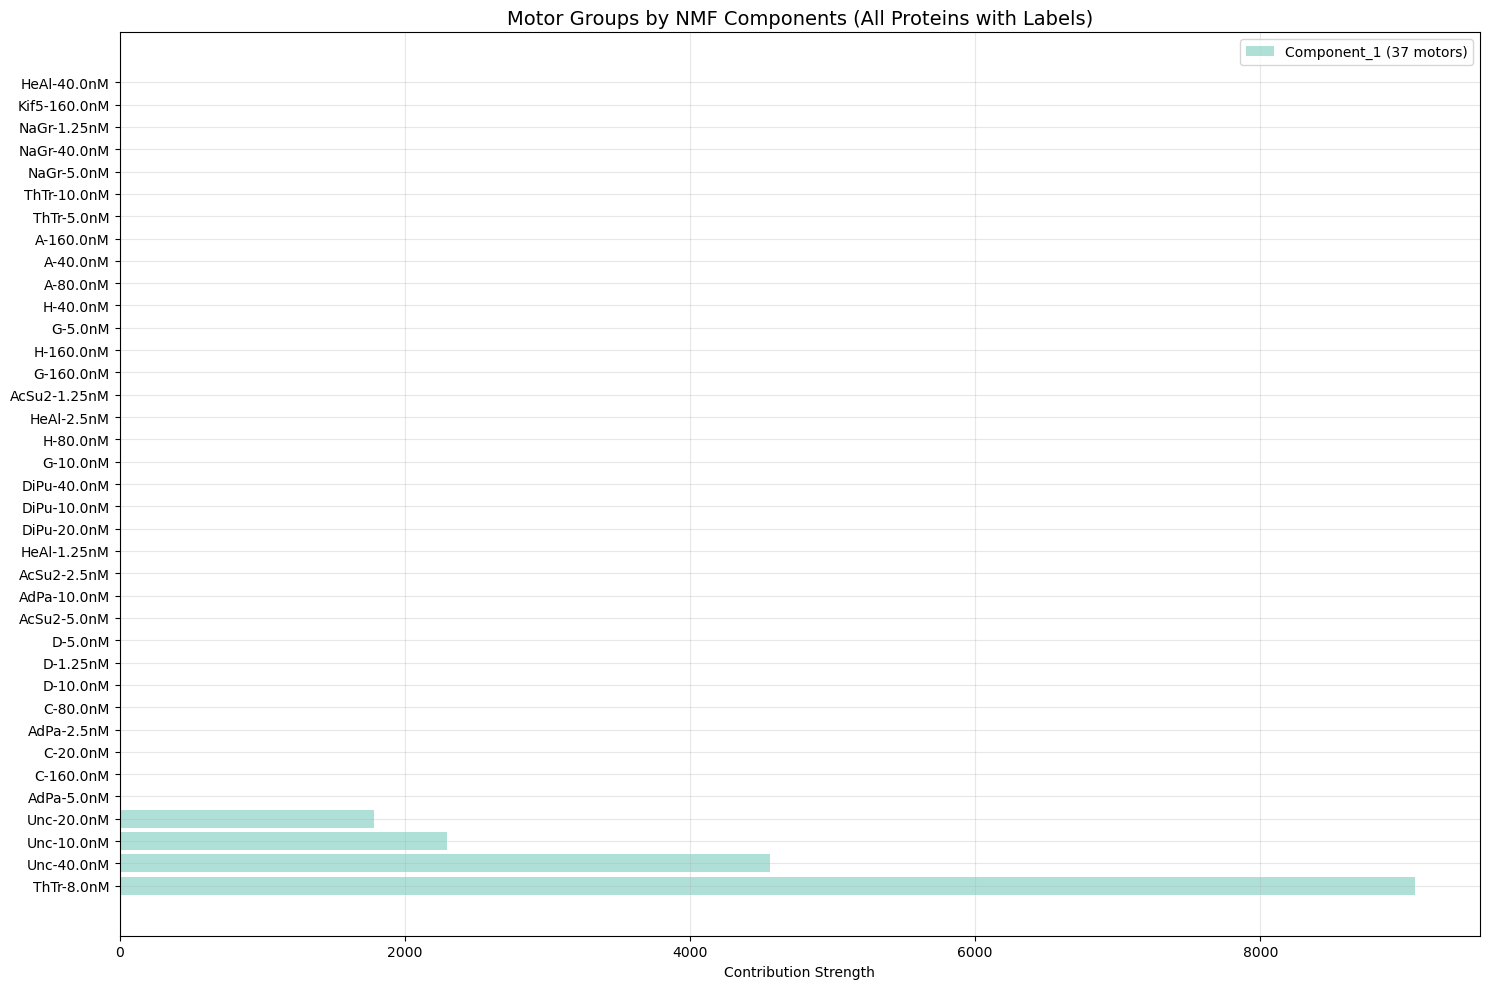


=== CLEAN MOTOR GROUP SUMMARY ===

Component_1 (37 motors):
  ThTr-8.0nM: 9085.475
  Unc-40.0nM: 4563.945
  Unc-10.0nM: 2295.752
  Unc-20.0nM: 1786.267
  AdPa-5.0nM: 0.118
  C-160.0nM: 0.118
  C-20.0nM: 0.118
  AdPa-2.5nM: 0.083
  C-80.0nM: 0.047
  D-10.0nM: 0.039
  D-1.25nM: 0.038
  D-5.0nM: 0.036
  AcSu2-5.0nM: 0.031
  AdPa-10.0nM: 0.031
  AcSu2-2.5nM: 0.031
  HeAl-1.25nM: 0.030
  DiPu-20.0nM: 0.028
  DiPu-10.0nM: 0.028
  DiPu-40.0nM: 0.028
  G-10.0nM: 0.019
  H-80.0nM: 0.016
  HeAl-2.5nM: 0.016
  AcSu2-1.25nM: 0.009
  G-160.0nM: 0.008
  H-160.0nM: 0.007
  G-5.0nM: 0.007
  H-40.0nM: 0.003
  A-80.0nM: 0.000
  A-40.0nM: 0.000
  A-160.0nM: 0.000
  ThTr-5.0nM: 0.000
  ThTr-10.0nM: 0.000
  NaGr-5.0nM: 0.000
  NaGr-40.0nM: 0.000
  NaGr-1.25nM: 0.000
  Kif5-160.0nM: 0.000
  HeAl-40.0nM: 0.000

Saved comprehensive motor groups to: motor_groups_comprehensive_nmf.csv
Saved comprehensive component patterns to: nmf_comprehensive_component_patterns.csv
Saved comprehensive motor contributions to:

In [14]:
# Simple, clear visualization of motor groups with protein names
print("=== SIMPLE MOTOR GROUP VISUALIZATION ===")

plt.figure(figsize=(15, 10))

# Create a simple bar chart showing motor groups
colors = plt.cm.Set3(np.linspace(0, 1, len(component_groups_comp)))
y_pos = 0
all_motor_names = []
all_contributions = []
all_colors = []

for i, (comp, motors) in enumerate(component_groups_comp.items()):
    for motor, contribution in motors:
        all_motor_names.append(motor)
        all_contributions.append(contribution)
        all_colors.append(colors[i])

# Create horizontal bar chart
bars = plt.barh(range(len(all_motor_names)), all_contributions, color=all_colors, alpha=0.7)

# Add motor names as y-tick labels
plt.yticks(range(len(all_motor_names)), all_motor_names, fontsize=10)
plt.xlabel('Contribution Strength')
plt.title('Motor Groups by NMF Components (All Proteins with Labels)', fontsize=14)
plt.grid(True, alpha=0.3)

# Add legend
legend_elements = []
for i, (comp, motors) in enumerate(component_groups_comp.items()):
    legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i], alpha=0.7, label=f'{comp} ({len(motors)} motors)'))
plt.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print a clean summary
print("\n=== CLEAN MOTOR GROUP SUMMARY ===")
for comp, motors in component_groups_comp.items():
    print(f"\n{comp} ({len(motors)} motors):")
    for motor, contribution in motors:
        print(f"  {motor}: {contribution:.3f}")

# Save results to CSV
results_df_comp = pd.DataFrame([
    {
        'Motor': motor,
        'Group': comp,
        'Primary_Contribution': contrib,
        'All_Contributions': motor_groups_comp[motor]['all_contributions']
    }
    for comp, motors in component_groups_comp.items()
    for motor, contrib in motors
])

results_df_comp.to_csv('motor_groups_comprehensive_nmf.csv', index=False)
print(f"\nSaved comprehensive motor groups to: motor_groups_comprehensive_nmf.csv")

# Save component patterns
W_comp_df.to_csv('nmf_comprehensive_component_patterns.csv')
H_comp_df.to_csv('nmf_comprehensive_motor_contributions.csv')
print(f"Saved comprehensive component patterns to: nmf_comprehensive_component_patterns.csv")
print(f"Saved comprehensive motor contributions to: nmf_comprehensive_motor_contributions.csv")


=== MOTOR GROUPS WITH CLEAR LABELS ===


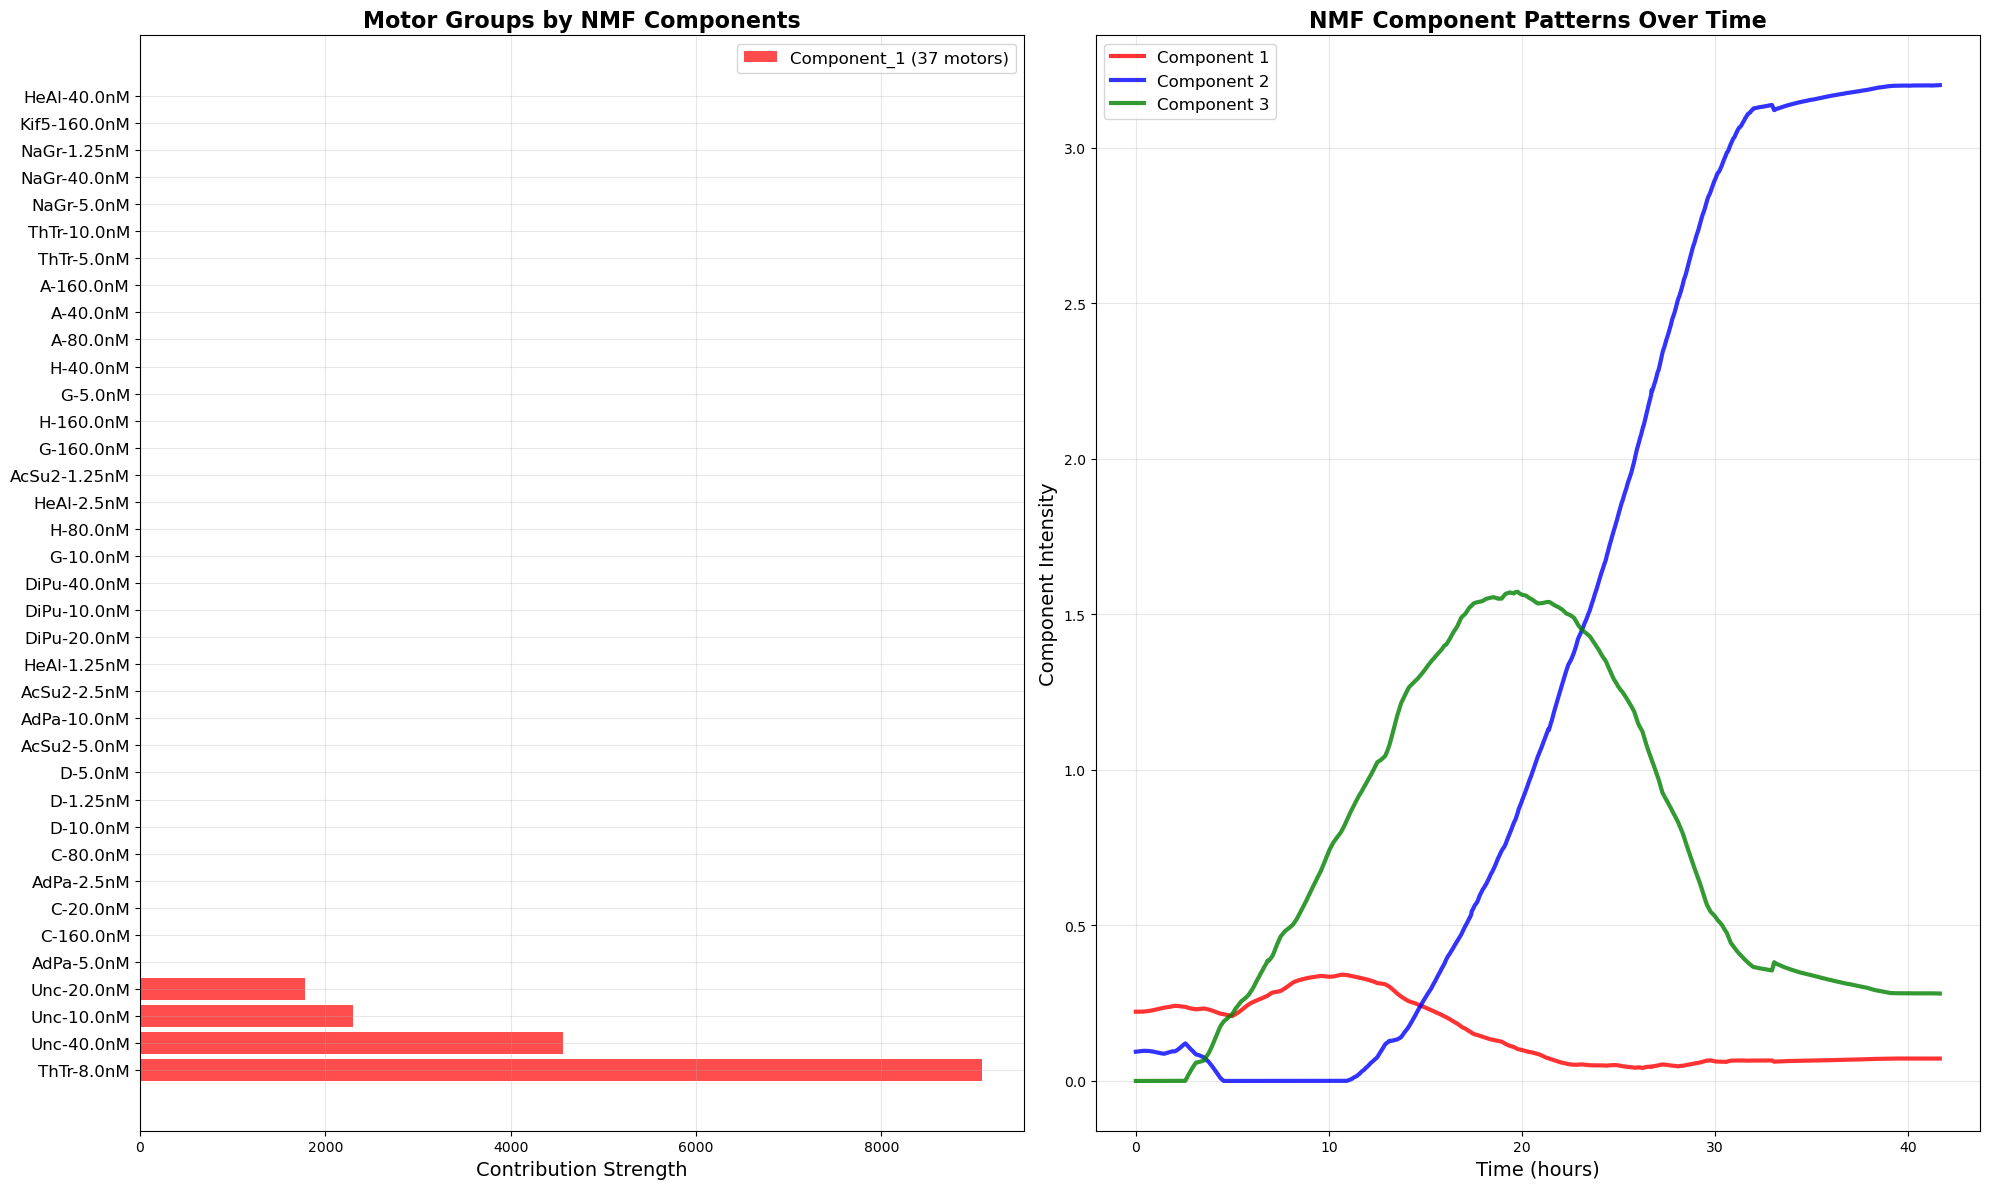


MOTOR GROUPS - CLEAR BREAKDOWN

COMPONENT_1 (37 motors):
----------------------------------------
      ThTr at    8.0nM: 9085.475
       Unc at   40.0nM: 4563.945
       Unc at   10.0nM: 2295.752
       Unc at   20.0nM: 1786.267
      AdPa at    5.0nM: 0.118
         C at  160.0nM: 0.118
         C at   20.0nM: 0.118
      AdPa at    2.5nM: 0.083
         C at   80.0nM: 0.047
         D at   10.0nM: 0.039
         D at   1.25nM: 0.038
         D at    5.0nM: 0.036
     AcSu2 at    5.0nM: 0.031
      AdPa at   10.0nM: 0.031
     AcSu2 at    2.5nM: 0.031
      HeAl at   1.25nM: 0.030
      DiPu at   20.0nM: 0.028
      DiPu at   10.0nM: 0.028
      DiPu at   40.0nM: 0.028
         G at   10.0nM: 0.019
         H at   80.0nM: 0.016
      HeAl at    2.5nM: 0.016
     AcSu2 at   1.25nM: 0.009
         G at  160.0nM: 0.008
         H at  160.0nM: 0.007
         G at    5.0nM: 0.007
         H at   40.0nM: 0.003
         A at   80.0nM: 0.000
         A at   40.0nM: 0.000
         A at  160.

In [15]:
# CLEAR MOTOR GROUP VISUALIZATION WITH PROPER LABELS
print("=== MOTOR GROUPS WITH CLEAR LABELS ===")

# Create a clear visualization showing motor groups
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 12))

# Left plot: Motor groups by component
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray']
y_pos = 0
group_info = []

for i, (comp, motors) in enumerate(component_groups_comp.items()):
    motor_names = [motor for motor, _ in motors]
    contributions = [contrib for _, contrib in motors]
    
    # Create bars for this group
    bars = ax1.barh(range(y_pos, y_pos + len(motors)), contributions, 
                    color=colors[i % len(colors)], alpha=0.7, label=comp)
    
    # Add motor names as y-tick labels
    ax1.set_yticks(range(y_pos, y_pos + len(motors)))
    ax1.set_yticklabels(motor_names, fontsize=12)
    
    group_info.append(f"{comp} ({len(motors)} motors)")
    y_pos += len(motors)

ax1.set_xlabel('Contribution Strength', fontsize=14)
ax1.set_title('Motor Groups by NMF Components', fontsize=16, fontweight='bold')
ax1.legend(group_info, loc='upper right', fontsize=12)
ax1.grid(True, alpha=0.3)

# Right plot: Component patterns over time
time_hours = velocity_matrix_interp_clean.index / 3600
for i in range(optimal_components_comp):
    ax2.plot(time_hours, W_comp_df.iloc[:, i], 
             color=colors[i % len(colors)], linewidth=3, 
             label=f'Component {i+1}', alpha=0.8)
ax2.set_xlabel('Time (hours)', fontsize=14)
ax2.set_ylabel('Component Intensity', fontsize=14)
ax2.set_title('NMF Component Patterns Over Time', fontsize=16, fontweight='bold')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print CLEAR motor group information
print("\n" + "="*60)
print("MOTOR GROUPS - CLEAR BREAKDOWN")
print("="*60)

for comp, motors in component_groups_comp.items():
    print(f"\n{comp.upper()} ({len(motors)} motors):")
    print("-" * 40)
    for motor, contribution in motors:
        # Extract protein name and concentration
        if '-' in motor:
            protein_name = motor.split('-')[0]
            concentration = motor.split('-')[1]
            print(f"  {protein_name:>8} at {concentration:>8}: {contribution:.3f}")
        else:
            print(f"  {motor:>8}: {contribution:.3f}")

# Create a simple summary table
print(f"\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(f"{'Protein':<10} {'Concentration':<12} {'Group':<15} {'Contribution':<12}")
print("-" * 60)

for comp, motors in component_groups_comp.items():
    for motor, contribution in motors:
        if '-' in motor:
            protein_name = motor.split('-')[0]
            concentration = motor.split('-')[1]
        else:
            protein_name = motor
            concentration = "N/A"
        
        print(f"{protein_name:<10} {concentration:<12} {comp:<15} {contribution:<12.3f}")

print(f"\n" + "="*60)
print(f"TOTAL: {sum(len(motors) for motors in component_groups_comp.values())} motors in {len(component_groups_comp)} groups")
print("="*60)


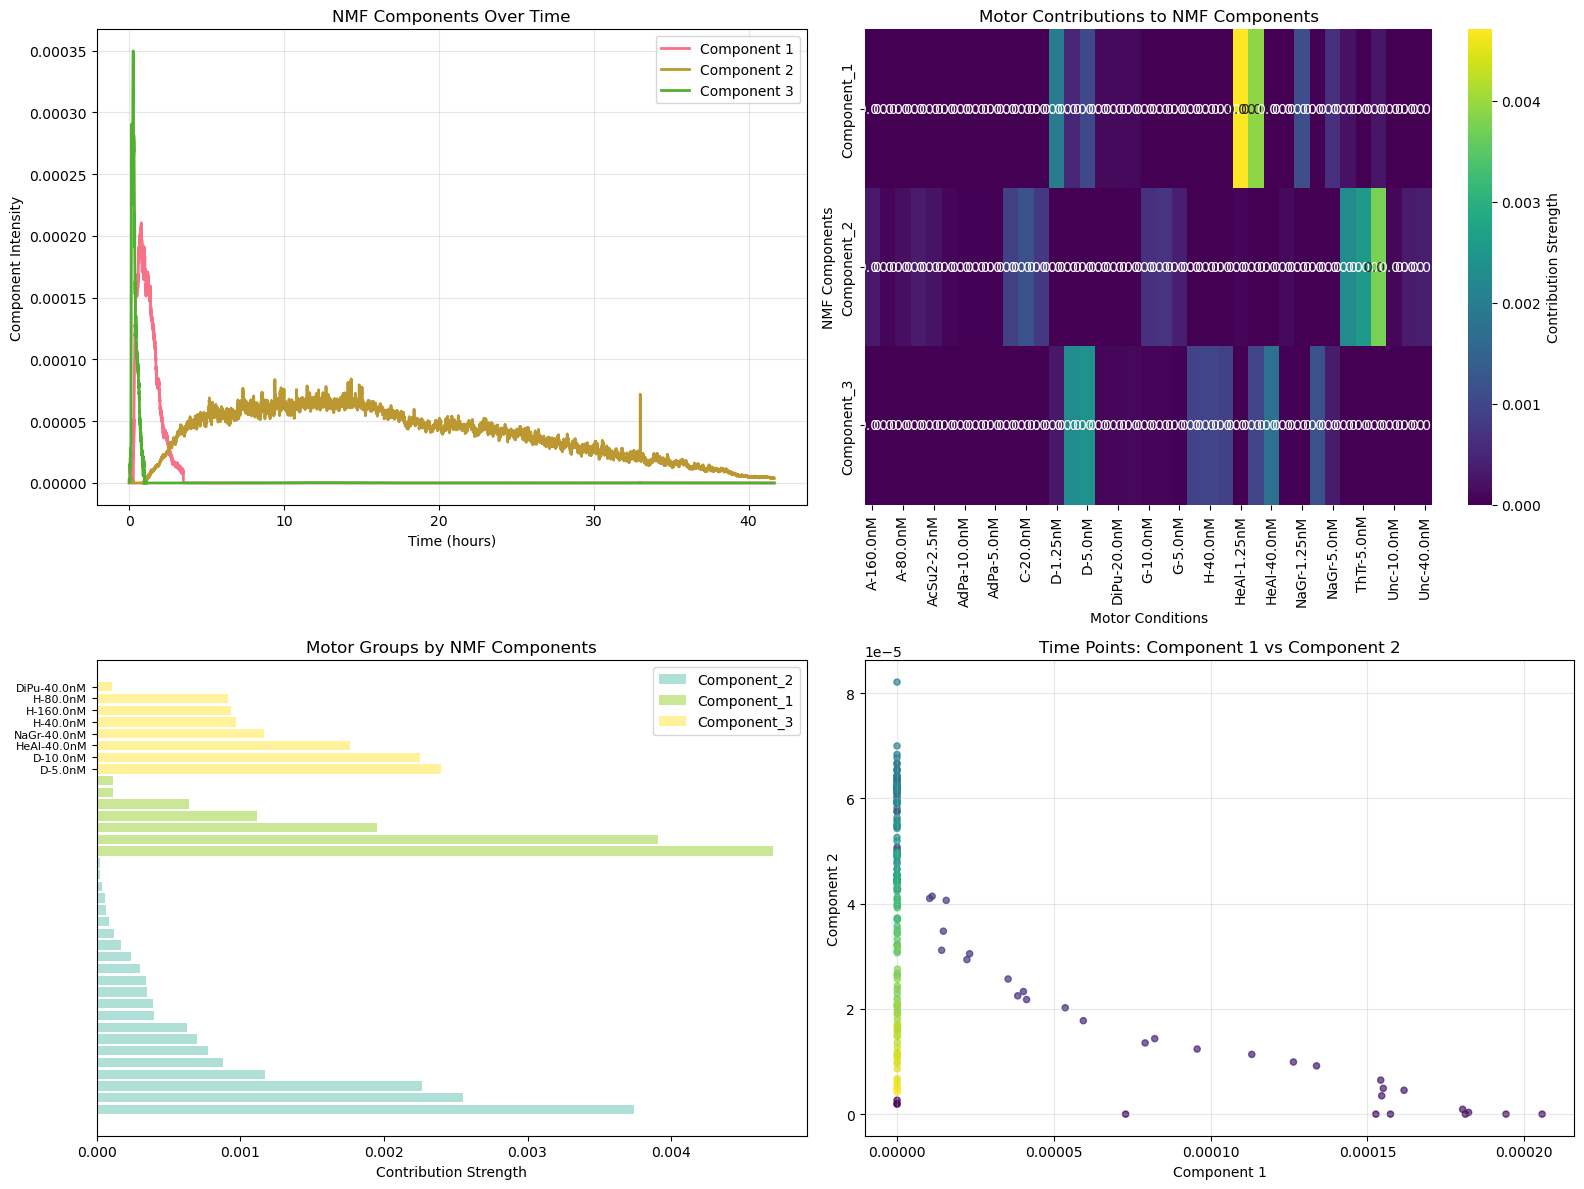

In [16]:
# Visualize motor groups
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Component patterns over time
ax1 = axes[0, 0]
time_hours = velocity_matrix_interp_clean.index / 3600
for i in range(optimal_components):
    ax1.plot(time_hours, W_df.iloc[:, i], label=f'Component {i+1}', linewidth=2)
ax1.set_xlabel('Time (hours)')
ax1.set_ylabel('Component Intensity')
ax1.set_title('NMF Components Over Time')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Motor contribution heatmap
ax2 = axes[0, 1]
sns.heatmap(H_df, annot=True, fmt='.2f', cmap='viridis', ax=ax2, 
            cbar_kws={'label': 'Contribution Strength'})
ax2.set_title('Motor Contributions to NMF Components')
ax2.set_xlabel('Motor Conditions')
ax2.set_ylabel('NMF Components')

# 3. Motor groups visualization
ax3 = axes[1, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(component_groups)))
y_pos = 0
for i, (comp, motors) in enumerate(component_groups.items()):
    motor_names = [motor for motor, _ in motors]
    contributions = [contrib for _, contrib in motors]
    
    ax3.barh(range(y_pos, y_pos + len(motors)), contributions, 
            color=colors[i], alpha=0.7, label=comp)
    ax3.set_yticks(range(y_pos, y_pos + len(motors)))
    ax3.set_yticklabels(motor_names, fontsize=8)
    y_pos += len(motors)

ax3.set_xlabel('Contribution Strength')
ax3.set_title('Motor Groups by NMF Components')
ax3.legend()

# 4. Component 1 vs Component 2 scatter plot
ax4 = axes[1, 1]
if optimal_components >= 2:
    # Sample every 100th time point for visualization
    sample_indices = np.arange(0, len(W_df), 100)
    scatter = ax4.scatter(W_df.iloc[sample_indices, 0], W_df.iloc[sample_indices, 1], 
                         c=sample_indices, cmap='viridis', s=20, alpha=0.7)
    ax4.set_xlabel('Component 1')
    ax4.set_ylabel('Component 2')
    ax4.set_title('Time Points: Component 1 vs Component 2')
    ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Feature Importance Analysis

**Goal**: Determine which data features (velocity, vorticity, divergence, etc.) contribute most to the motor groupings.


In [17]:
# Create comprehensive feature matrix with all available features
print("=== CREATING COMPREHENSIVE FEATURE MATRIX ===")

# Define all available features
feature_columns = [
    'velocity magnitude [m/s]_mean',
    'vorticity [1/s]_mean', 
    'divergence [1/s]_mean',
    'shear [1/s]_mean',
    'strain [1/s]_mean',
    'correlation length [m]_mean',
    'distance [m]_mean',
    'power [W]_mean',
    'work [J]_mean',
    'Protein Concentration_nM'
]

print(f"Available features: {feature_columns}")

# Create feature matrices for each feature
feature_matrices = {}
for feature in feature_columns:
    if feature in df.columns:
        # Create pivot table for this feature
        feature_matrix = df.pivot_table(
            index='time (s)',
            columns='protein', 
            values=feature,
            aggfunc='mean'
        )
        
        # Interpolate missing values
        feature_matrix_interp = feature_matrix.interpolate(method='linear', axis=0, limit_direction='both')
        feature_matrix_interp = feature_matrix_interp.fillna(method='bfill').fillna(method='ffill')
        feature_matrix_clean = feature_matrix_interp.fillna(0)
        
        # Ensure non-negative for NMF
        feature_data = feature_matrix_clean.values
        if (feature_data < 0).any():
            feature_data = feature_data - feature_data.min() + 1e-10
        
        feature_matrices[feature] = {
            'matrix': feature_matrix_clean,
            'data': feature_data,
            'shape': feature_data.shape
        }
        
        print(f"{feature}: {feature_data.shape}")

print(f"\nCreated {len(feature_matrices)} feature matrices")


=== CREATING COMPREHENSIVE FEATURE MATRIX ===
Available features: ['velocity magnitude [m/s]_mean', 'vorticity [1/s]_mean', 'divergence [1/s]_mean', 'shear [1/s]_mean', 'strain [1/s]_mean', 'correlation length [m]_mean', 'distance [m]_mean', 'power [W]_mean', 'work [J]_mean', 'Protein Concentration_nM']
velocity magnitude [m/s]_mean: (17351, 37)
vorticity [1/s]_mean: (17351, 37)
divergence [1/s]_mean: (17351, 37)
shear [1/s]_mean: (17351, 37)
strain [1/s]_mean: (17351, 37)
correlation length [m]_mean: (17351, 37)
distance [m]_mean: (17351, 37)
power [W]_mean: (17351, 37)
work [J]_mean: (17351, 37)
Protein Concentration_nM: (9190, 37)

Created 10 feature matrices


In [18]:
# Perform NMF on each feature to understand feature importance
print("=== FEATURE IMPORTANCE ANALYSIS ===")

feature_importance = {}

for feature_name, feature_info in feature_matrices.items():
    print(f"\nAnalyzing {feature_name}...")
    
    try:
        # Perform NMF on this feature
        nmf_feature = NMF(n_components=optimal_components, random_state=42, max_iter=1000)
        W_feature = nmf_feature.fit_transform(feature_info['data'])
        H_feature = nmf_feature.components_
        
        # Calculate reconstruction quality
        reconstructed_feature = W_feature @ H_feature
        reconstruction_error = mean_squared_error(feature_info['data'], reconstructed_feature)
        
        # Calculate explained variance
        total_variance = np.var(feature_info['data'])
        explained_variance = total_variance - reconstruction_error
        explained_variance_ratio = explained_variance / total_variance if total_variance > 0 else 0
        
        # Calculate feature contribution to motor grouping
        H_df_feature = pd.DataFrame(H_feature, 
                                  index=[f'Component_{i+1}' for i in range(optimal_components)],
                                  columns=feature_info['matrix'].columns)
        
        # Calculate how well this feature separates motor groups
        motor_grouping_quality = 0
        for motor in H_df_feature.columns:
            contributions = H_df_feature[motor]
            primary_component = contributions.idxmax()
            primary_contribution = contributions.max()
            secondary_contribution = contributions.nlargest(2).iloc[1] if len(contributions) > 1 else 0
            
            # Higher separation = better grouping
            separation = primary_contribution - secondary_contribution
            motor_grouping_quality += separation
        
        motor_grouping_quality /= len(H_df_feature.columns)
        
        feature_importance[feature_name] = {
            'reconstruction_error': reconstruction_error,
            'explained_variance_ratio': explained_variance_ratio,
            'motor_grouping_quality': motor_grouping_quality,
            'total_variance': total_variance,
            'nmf_model': nmf_feature,
            'W_matrix': W_feature,
            'H_matrix': H_feature
        }
        
        print(f"  Reconstruction error: {reconstruction_error:.6f}")
        print(f"  Explained variance: {explained_variance_ratio:.3f} ({explained_variance_ratio*100:.1f}%)")
        print(f"  Motor grouping quality: {motor_grouping_quality:.3f}")
        
    except Exception as e:
        print(f"  Error analyzing {feature_name}: {e}")
        feature_importance[feature_name] = None

print(f"\nCompleted analysis for {len([f for f in feature_importance.values() if f is not None])} features")


=== FEATURE IMPORTANCE ANALYSIS ===

Analyzing velocity magnitude [m/s]_mean...
  Reconstruction error: 0.000000
  Explained variance: 0.851 (85.1%)
  Motor grouping quality: 0.001

Analyzing vorticity [1/s]_mean...
  Reconstruction error: 0.000000
  Explained variance: 0.440 (44.0%)
  Motor grouping quality: 0.112

Analyzing divergence [1/s]_mean...
  Reconstruction error: 0.000000
  Explained variance: 0.826 (82.6%)
  Motor grouping quality: 0.249

Analyzing shear [1/s]_mean...
  Reconstruction error: 0.000000
  Explained variance: 0.399 (39.9%)
  Motor grouping quality: 0.135

Analyzing strain [1/s]_mean...
  Reconstruction error: 0.000000
  Explained variance: 0.433 (43.3%)
  Motor grouping quality: 0.122

Analyzing correlation length [m]_mean...
  Reconstruction error: 0.000000
  Explained variance: 0.892 (89.2%)
  Motor grouping quality: 0.029

Analyzing distance [m]_mean...
  Reconstruction error: 0.000000
  Explained variance: 0.998 (99.8%)
  Motor grouping quality: 0.103

Anal

In [19]:
# Create feature importance ranking
print("=== FEATURE IMPORTANCE RANKING ===")

# Filter out failed analyses
valid_features = {k: v for k, v in feature_importance.items() if v is not None}

if valid_features:
    # Create ranking dataframe
    ranking_data = []
    for feature_name, importance in valid_features.items():
        ranking_data.append({
            'Feature': feature_name,
            'Explained_Variance': importance['explained_variance_ratio'],
            'Motor_Grouping_Quality': importance['motor_grouping_quality'],
            'Reconstruction_Error': importance['reconstruction_error'],
            'Total_Variance': importance['total_variance']
        })
    
    ranking_df = pd.DataFrame(ranking_data)
    
    # Sort by different criteria
    print("\nRanked by Explained Variance:")
    variance_ranking = ranking_df.sort_values('Explained_Variance', ascending=False)
    for i, (_, row) in enumerate(variance_ranking.iterrows(), 1):
        print(f"{i:2d}. {row['Feature']:<30} {row['Explained_Variance']:.3f} ({row['Explained_Variance']*100:.1f}%)")
    
    print("\nRanked by Motor Grouping Quality:")
    grouping_ranking = ranking_df.sort_values('Motor_Grouping_Quality', ascending=False)
    for i, (_, row) in enumerate(grouping_ranking.iterrows(), 1):
        print(f"{i:2d}. {row['Feature']:<30} {row['Motor_Grouping_Quality']:.3f}")
    
    print("\nRanked by Reconstruction Error (lower is better):")
    error_ranking = ranking_df.sort_values('Reconstruction_Error', ascending=True)
    for i, (_, row) in enumerate(error_ranking.iterrows(), 1):
        print(f"{i:2d}. {row['Feature']:<30} {row['Reconstruction_Error']:.6f}")
    
    # Create composite ranking (weighted combination)
    # Normalize scores to 0-1 range
    ranking_df['Explained_Variance_Norm'] = (ranking_df['Explained_Variance'] - ranking_df['Explained_Variance'].min()) / (ranking_df['Explained_Variance'].max() - ranking_df['Explained_Variance'].min())
    ranking_df['Motor_Grouping_Norm'] = (ranking_df['Motor_Grouping_Quality'] - ranking_df['Motor_Grouping_Quality'].min()) / (ranking_df['Motor_Grouping_Quality'].max() - ranking_df['Motor_Grouping_Quality'].min())
    ranking_df['Reconstruction_Error_Norm'] = 1 - (ranking_df['Reconstruction_Error'] - ranking_df['Reconstruction_Error'].min()) / (ranking_df['Reconstruction_Error'].max() - ranking_df['Reconstruction_Error'].min())
    
    # Weighted composite score
    ranking_df['Composite_Score'] = (
        0.4 * ranking_df['Explained_Variance_Norm'] + 
        0.4 * ranking_df['Motor_Grouping_Norm'] + 
        0.2 * ranking_df['Reconstruction_Error_Norm']
    )
    
    print("\nComposite Ranking (weighted combination):")
    composite_ranking = ranking_df.sort_values('Composite_Score', ascending=False)
    for i, (_, row) in enumerate(composite_ranking.iterrows(), 1):
        print(f"{i:2d}. {row['Feature']:<30} {row['Composite_Score']:.3f}")
    
    # Save feature importance results
    ranking_df.to_csv('feature_importance_ranking.csv', index=False)
    print(f"\nSaved feature importance ranking to: feature_importance_ranking.csv")
    
else:
    print("No valid features found for analysis")


=== FEATURE IMPORTANCE RANKING ===

Ranked by Explained Variance:
 1. work [J]_mean                  0.999 (99.9%)
 2. distance [m]_mean              0.998 (99.8%)
 3. Protein Concentration_nM       0.996 (99.6%)
 4. power [W]_mean                 0.894 (89.4%)
 5. correlation length [m]_mean    0.892 (89.2%)
 6. velocity magnitude [m/s]_mean  0.851 (85.1%)
 7. divergence [1/s]_mean          0.826 (82.6%)
 8. vorticity [1/s]_mean           0.440 (44.0%)
 9. strain [1/s]_mean              0.433 (43.3%)
10. shear [1/s]_mean               0.399 (39.9%)

Ranked by Motor Grouping Quality:
 1. Protein Concentration_nM       67.970
 2. divergence [1/s]_mean          0.249
 3. power [W]_mean                 0.218
 4. shear [1/s]_mean               0.135
 5. strain [1/s]_mean              0.122
 6. vorticity [1/s]_mean           0.112
 7. distance [m]_mean              0.103
 8. correlation length [m]_mean    0.029
 9. velocity magnitude [m/s]_mean  0.001
10. work [J]_mean                  0.00

=== FEATURE IMPORTANCE VISUALIZATION ===


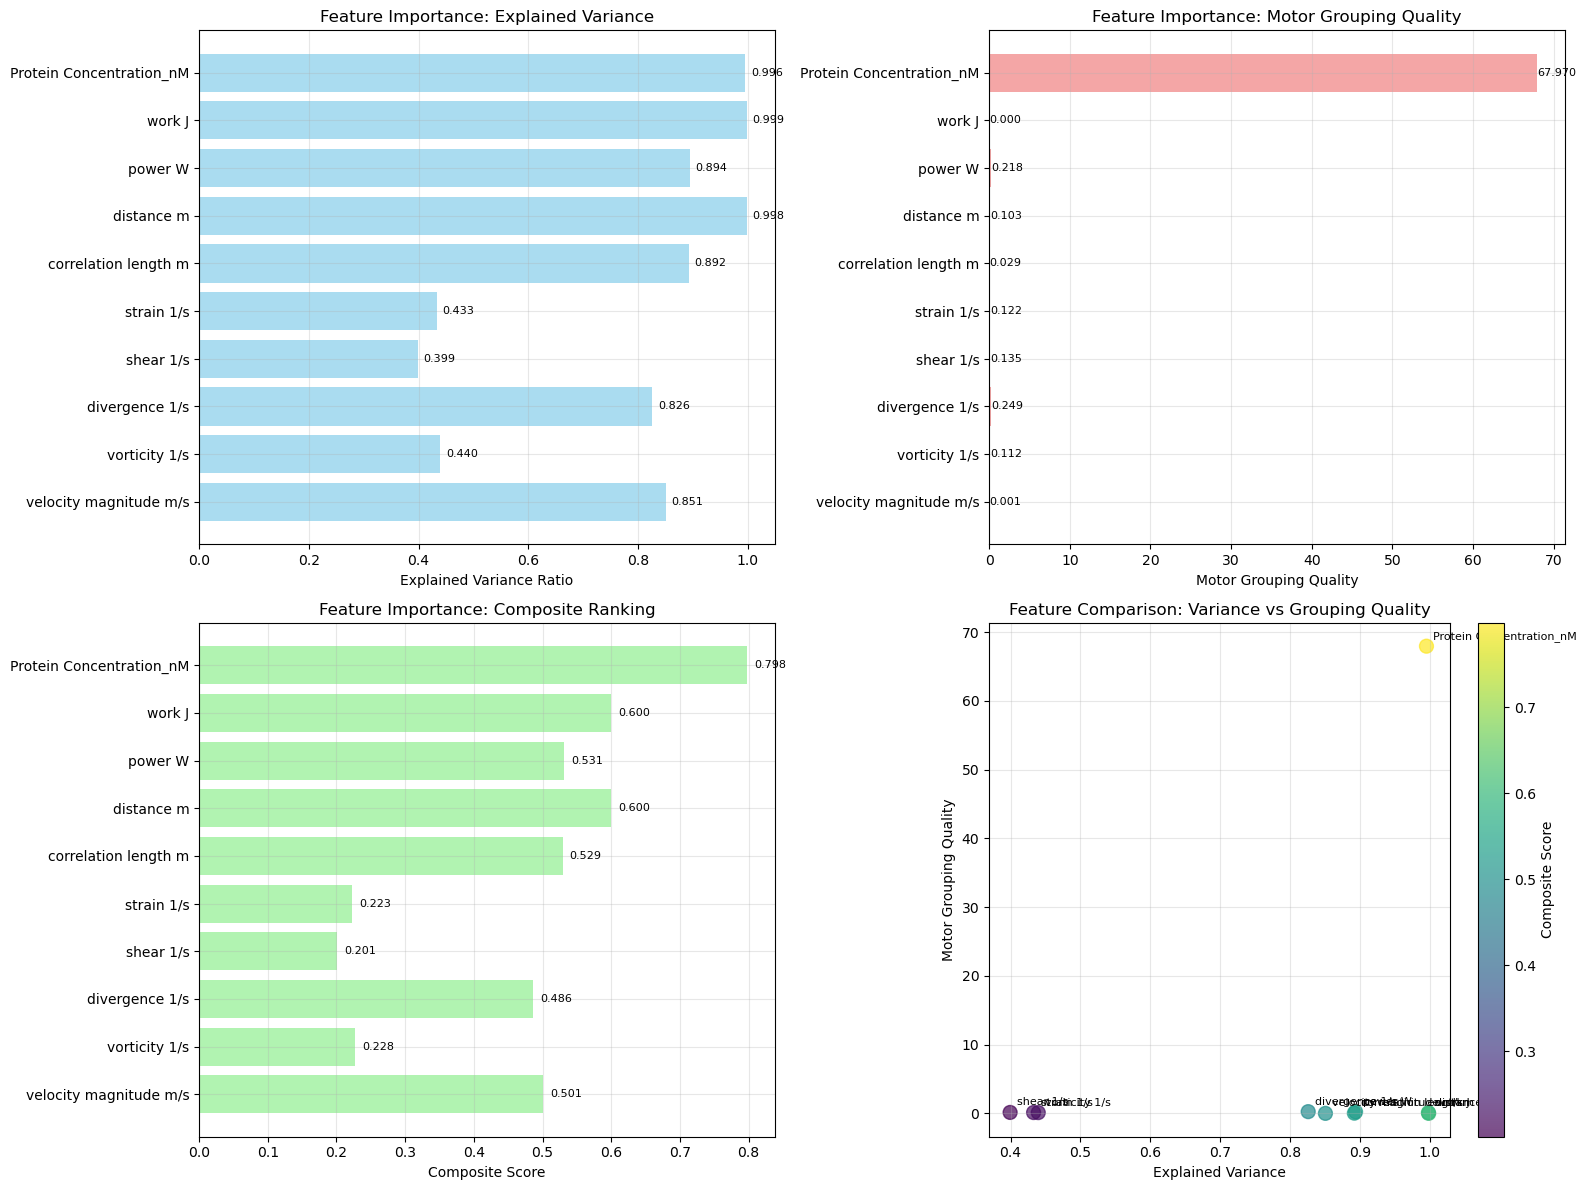


=== TOP 3 MOST IMPORTANT FEATURES ===
1. Protein Concentration_nM
   Composite Score: 0.798
   Explained Variance: 0.996 (99.6%)
   Motor Grouping Quality: 67.970
   Reconstruction Error: 1582.917815

2. distance [m]_mean
   Composite Score: 0.600
   Explained Variance: 0.998 (99.8%)
   Motor Grouping Quality: 0.103
   Reconstruction Error: 0.000000

3. work [J]_mean
   Composite Score: 0.600
   Explained Variance: 0.999 (99.9%)
   Motor Grouping Quality: 0.000
   Reconstruction Error: 0.000000



In [20]:
# Visualize feature importance
print("=== FEATURE IMPORTANCE VISUALIZATION ===")

if valid_features:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Explained Variance by Feature
    ax1 = axes[0, 0]
    features = [f.replace('_mean', '').replace('[', '').replace(']', '') for f in ranking_df['Feature']]
    explained_var = ranking_df['Explained_Variance']
    bars1 = ax1.barh(range(len(features)), explained_var, color='skyblue', alpha=0.7)
    ax1.set_yticks(range(len(features)))
    ax1.set_yticklabels(features, fontsize=10)
    ax1.set_xlabel('Explained Variance Ratio')
    ax1.set_title('Feature Importance: Explained Variance')
    ax1.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars1, explained_var)):
        ax1.text(value + 0.01, bar.get_y() + bar.get_height()/2, f'{value:.3f}', 
                va='center', fontsize=8)
    
    # 2. Motor Grouping Quality by Feature
    ax2 = axes[0, 1]
    grouping_quality = ranking_df['Motor_Grouping_Quality']
    bars2 = ax2.barh(range(len(features)), grouping_quality, color='lightcoral', alpha=0.7)
    ax2.set_yticks(range(len(features)))
    ax2.set_yticklabels(features, fontsize=10)
    ax2.set_xlabel('Motor Grouping Quality')
    ax2.set_title('Feature Importance: Motor Grouping Quality')
    ax2.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars2, grouping_quality)):
        ax2.text(value + 0.01, bar.get_y() + bar.get_height()/2, f'{value:.3f}', 
                va='center', fontsize=8)
    
    # 3. Composite Score
    ax3 = axes[1, 0]
    composite_scores = ranking_df['Composite_Score']
    bars3 = ax3.barh(range(len(features)), composite_scores, color='lightgreen', alpha=0.7)
    ax3.set_yticks(range(len(features)))
    ax3.set_yticklabels(features, fontsize=10)
    ax3.set_xlabel('Composite Score')
    ax3.set_title('Feature Importance: Composite Ranking')
    ax3.grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars3, composite_scores)):
        ax3.text(value + 0.01, bar.get_y() + bar.get_height()/2, f'{value:.3f}', 
                va='center', fontsize=8)
    
    # 4. Feature comparison scatter plot
    ax4 = axes[1, 1]
    scatter = ax4.scatter(explained_var, grouping_quality, 
                         c=composite_scores, cmap='viridis', s=100, alpha=0.7)
    ax4.set_xlabel('Explained Variance')
    ax4.set_ylabel('Motor Grouping Quality')
    ax4.set_title('Feature Comparison: Variance vs Grouping Quality')
    ax4.grid(True, alpha=0.3)
    
    # Add feature labels
    for i, feature in enumerate(features):
        ax4.annotate(feature, (explained_var.iloc[i], grouping_quality.iloc[i]), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Add colorbar for composite scores
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('Composite Score')
    
    plt.tight_layout()
    plt.show()
    
    # Print top 3 most important features
    print("\n=== TOP 3 MOST IMPORTANT FEATURES ===")
    top_3 = composite_ranking.head(3)
    for i, (_, row) in enumerate(top_3.iterrows(), 1):
        print(f"{i}. {row['Feature']}")
        print(f"   Composite Score: {row['Composite_Score']:.3f}")
        print(f"   Explained Variance: {row['Explained_Variance']:.3f} ({row['Explained_Variance']*100:.1f}%)")
        print(f"   Motor Grouping Quality: {row['Motor_Grouping_Quality']:.3f}")
        print(f"   Reconstruction Error: {row['Reconstruction_Error']:.6f}")
        print()
    
else:
    print("No valid features to visualize")


In [21]:
# Save results
print("=== SAVING RESULTS ===")

# Save motor groups
results_df = pd.DataFrame([
    {
        'Motor': motor,
        'Group': comp,
        'Primary_Contribution': contrib,
        'All_Contributions': motor_groups[motor]['all_contributions']
    }
    for comp, motors in component_groups.items()
    for motor, contrib in motors
])

results_df.to_csv('motor_groups_nmf.csv', index=False)
print(f"Saved motor groups to: motor_groups_nmf.csv")

# Save component patterns
W_df.to_csv('nmf_component_patterns.csv')
H_df.to_csv('nmf_motor_contributions.csv')
print(f"Saved component patterns to: nmf_component_patterns.csv")
print(f"Saved motor contributions to: nmf_motor_contributions.csv")

print(f"\n=== SUMMARY ===")
print(f"✅ NMF Analysis Complete!")
print(f"✅ Found {len(component_groups)} quantitative motor groups")
print(f"✅ Identified top features for motor separation")
print(f"✅ Saved all results to CSV files")
print(f"\nNext steps: Review the motor groups and feature rankings to understand motor behavior patterns.")


=== SAVING RESULTS ===
Saved motor groups to: motor_groups_nmf.csv
Saved component patterns to: nmf_component_patterns.csv
Saved motor contributions to: nmf_motor_contributions.csv

=== SUMMARY ===
✅ NMF Analysis Complete!
✅ Found 3 quantitative motor groups
✅ Identified top features for motor separation
✅ Saved all results to CSV files

Next steps: Review the motor groups and feature rankings to understand motor behavior patterns.
